# Data loading

In [1]:
import pandas as pd
import numpy as np

data_path = "WDI_Source_Data.csv"

raw = pd.read_csv(data_path)

In [2]:
brics = ["Brazil", "Russian Federation", "India", "China", "South Africa"]

df = raw[raw["Country Name"].isin(brics)].copy()

year_cols = [col for col in df.columns if "[YR" in col]

# Convert from wide format to long format
long_df = df.melt(
    id_vars=["Country Name", "Country Code", "Series Name", "Series Code"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Value"
)

long_df["Year"] = long_df["Year"].str.extract(r"(\d{4})").astype(int)

long_df["Value"] = pd.to_numeric(long_df["Value"], errors="coerce")

# Rename indicators into cleaner variable names
indicator_map = {
    "Carbon intensity of GDP (kg CO2e per constant 2015 US$ of GDP)": "carbon_intensity",
    "GDP (constant 2015 US$)": "gdp_constant_2015_usd",
    "Urban population growth (annual %)": "urban_population_growth",
    "Urban population (% of total population)": "urban_population_pct",
    "Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)": "co2_per_capita",
    "Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)": "co2_total_mt"
}

long_df["Variable"] = long_df["Series Name"].map(indicator_map)

# Reshape into final panel dataset
panel_df = long_df.pivot_table(
    index=["Country Name", "Country Code", "Year"],
    columns="Variable",
    values="Value"
).reset_index()

panel_df = panel_df.rename(columns={
    "Country Name": "country",
    "Country Code": "country_code"
})

panel_df = panel_df.sort_values(["country", "Year"]).reset_index(drop=True)

print(panel_df.shape)
print(panel_df.head())
print(panel_df.isna().sum())

(125, 9)
Variable country country_code  Year  carbon_intensity  co2_per_capita  \
0         Brazil          BRA  2000          0.294506        2.007879   
1         Brazil          BRA  2001          0.292073        1.992821   
2         Brazil          BRA  2002          0.283499        1.968796   
3         Brazil          BRA  2003          0.276368        1.918394   
4         Brazil          BRA  2004          0.275498        1.999783   

Variable  co2_total_mt  gdp_constant_2015_usd  urban_population_growth  \
0             349.4076           1.186419e+12                 2.119616   
1             351.3367           1.202909e+12                 1.853432   
2             351.4370           1.239639e+12                 1.728375   
3             346.5055           1.253781e+12                 1.617924   
4             365.3106           1.325999e+12                 1.526979   

Variable  urban_population_pct  
0                    81.148437  
1                    81.596045  
2       

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 0 to 29
Data columns (total 29 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country Name   30 non-null     object 
 1   Country Code   30 non-null     object 
 2   Series Name    30 non-null     object 
 3   Series Code    30 non-null     object 
 4   2000 [YR2000]  30 non-null     float64
 5   2001 [YR2001]  30 non-null     float64
 6   2002 [YR2002]  30 non-null     float64
 7   2003 [YR2003]  30 non-null     float64
 8   2004 [YR2004]  30 non-null     float64
 9   2005 [YR2005]  30 non-null     float64
 10  2006 [YR2006]  30 non-null     float64
 11  2007 [YR2007]  30 non-null     float64
 12  2008 [YR2008]  30 non-null     float64
 13  2009 [YR2009]  30 non-null     float64
 14  2010 [YR2010]  30 non-null     float64
 15  2011 [YR2011]  30 non-null     float64
 16  2012 [YR2012]  30 non-null     float64
 17  2013 [YR2013]  30 non-null     float64
 18  2014 [YR2014]  30

In [ ]:
panel_df.to_csv("BRICS_Panel_2000_2024.csv", index=False)

# EDA

In [4]:
df = panel_df.copy()

summary = (
    df[
        [
            "carbon_intensity",
            "co2_per_capita",
            "co2_total_mt",
            "gdp_constant_2015_usd",
            "urban_population_growth",
            "urban_population_pct",
        ]
    ]
    .agg(["mean", "std", "min", "median", "max"])
    .T
)

summary.columns = ["Mean", "Std", "Min", "Median", "Max"]
summary = summary.round(3)

summary

,Mean,Std,Min,Median,Max
Variable,,,,,
carbon_intensity,1.061000e+00,4.670000e-01,2.420000e-01,1.182000e+00,2.154000e+00
co2_per_capita,6.190000e+00,4.149000e+00,9.400000e-01,6.877000e+00,1.399800e+01
co2_total_mt,2.749846e+03,3.553338e+03,3.465060e+02,1.681152e+03,1.312473e+04
gdp_constant_2015_usd,2.934294e+12,4.059528e+12,2.216920e+11,1.461551e+12,1.848811e+13
urban_population_growth,1.682000e+00,1.234000e+00,-5.800000e-01,1.728000e+00,5.685000e+00
urban_population_pct,6.090900e+01,1.895900e+01,2.764700e+01,6.333100e+01,8.789600e+01


In [5]:
summary.index = [
    "Carbon intensity",
    "CO₂ emissions per capita",
    "Total CO₂ emissions",
    "GDP (constant 2015 US$)",
    "Urban population growth",
    "Urban population (%)",
]

summary

,Mean,Std,Min,Median,Max
Carbon intensity,1.061000e+00,4.670000e-01,2.420000e-01,1.182000e+00,2.154000e+00
CO₂ emissions per capita,6.190000e+00,4.149000e+00,9.400000e-01,6.877000e+00,1.399800e+01
Total CO₂ emissions,2.749846e+03,3.553338e+03,3.465060e+02,1.681152e+03,1.312473e+04
GDP (constant 2015 US$),2.934294e+12,4.059528e+12,2.216920e+11,1.461551e+12,1.848811e+13
Urban population growth,1.682000e+00,1.234000e+00,-5.800000e-01,1.728000e+00,5.685000e+00
Urban population (%),6.090900e+01,1.895900e+01,2.764700e+01,6.333100e+01,8.789600e+01


In [6]:
pd.set_option("display.float_format", "{:.3f}".format)
summary

,Mean,Std,Min,Median,Max
Carbon intensity,1.061,0.467,0.242,1.182,2.154
CO₂ emissions per capita,6.190,4.149,0.940,6.877,13.998
Total CO₂ emissions,2749.846,3553.338,346.506,1681.152,13124.728
GDP (constant 2015 US$),2934293746802.466,4059528011298.426,221691970228.101,1461551317106.210,18488114837769.301
Urban population growth,1.682,1.234,-0.580,1.728,5.685
Urban population (%),60.909,18.959,27.647,63.331,87.896


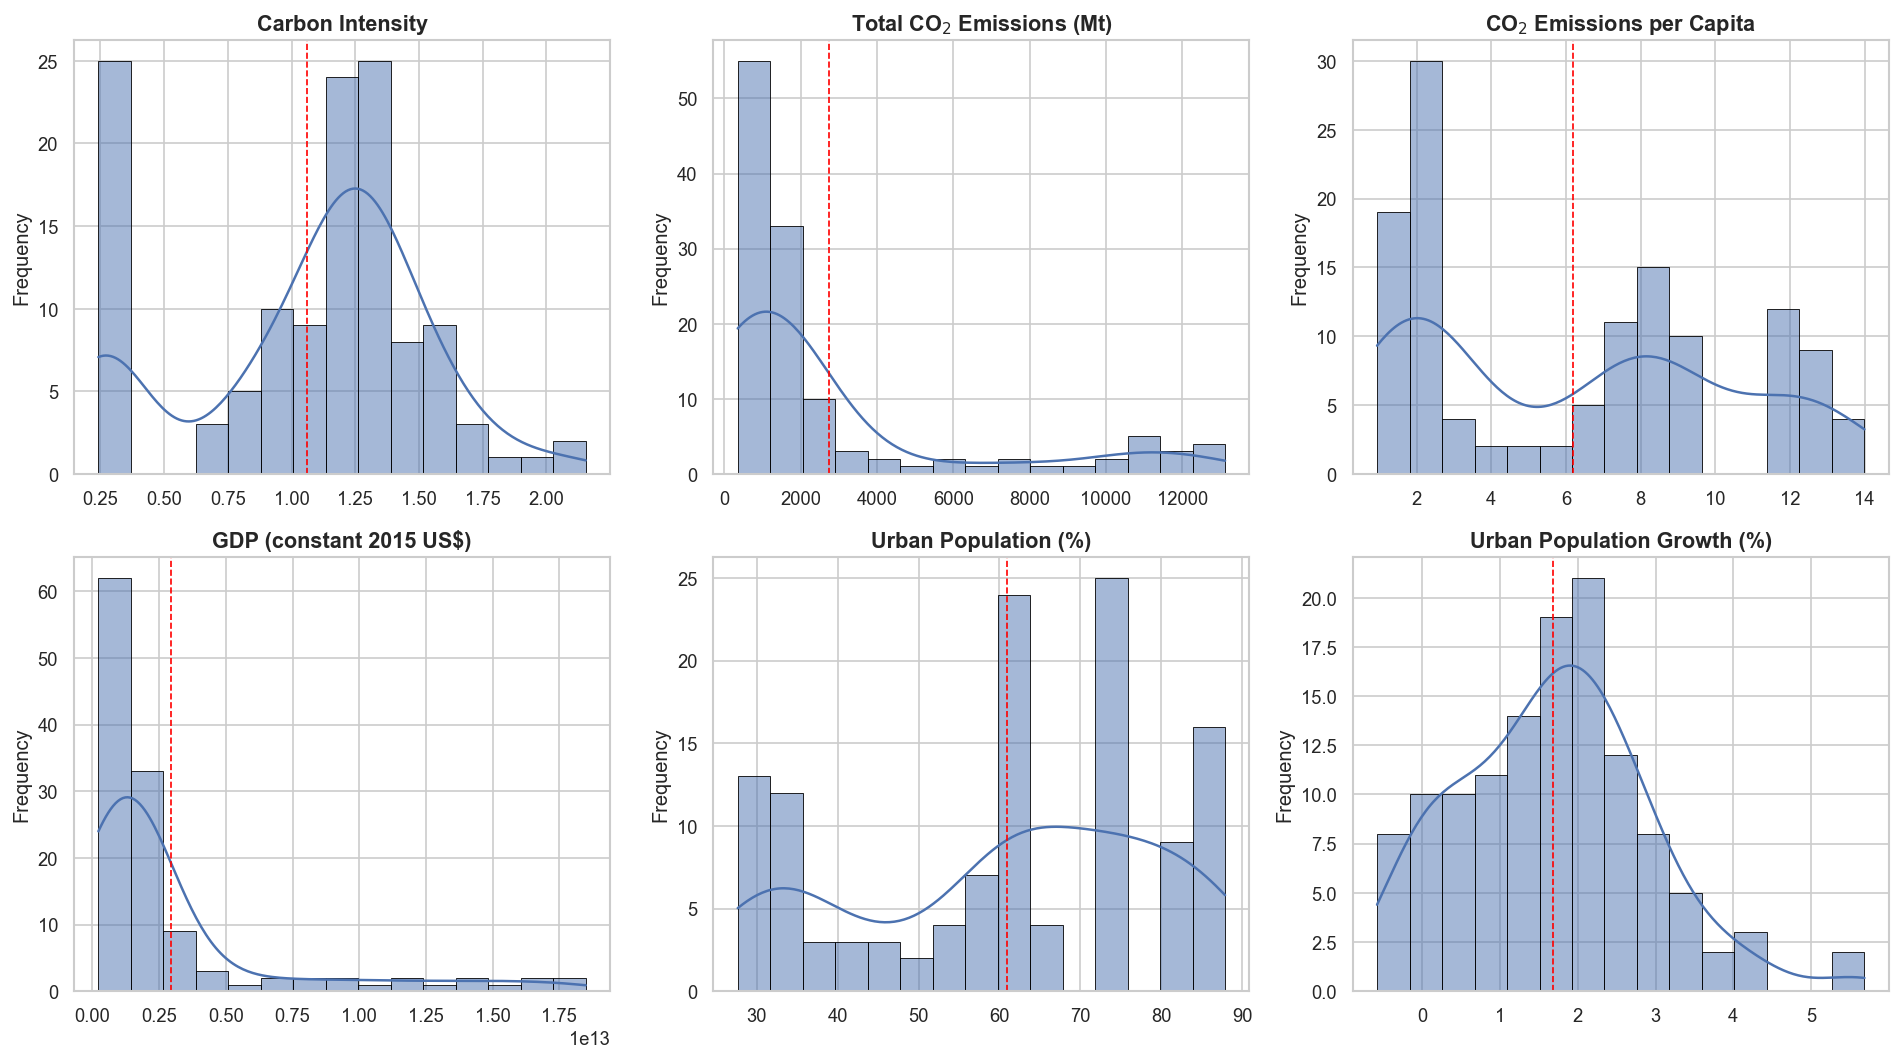

In [7]:
# Distribution
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

variables = {
    "carbon_intensity": "Carbon Intensity",
    "co2_total_mt": r"Total CO$_2$ Emissions (Mt)",
    "co2_per_capita": r"CO$_2$ Emissions per Capita",
    "gdp_constant_2015_usd": "GDP (constant 2015 US$)",
    "urban_population_pct": "Urban Population (%)",
    "urban_population_growth": "Urban Population Growth (%)"
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (col, title) in zip(axes, variables.items()):

    sns.histplot(
        data=df,
        x=col,
        bins=15,
        kde=True,
        color="#4C72B0",
        edgecolor="black",
        linewidth=0.5,
        ax=ax
    )

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")
    ax.axvline(
    df[col].mean(),
    color="red",
    linestyle="--",
    linewidth=1
)

plt.tight_layout()
plt.show()

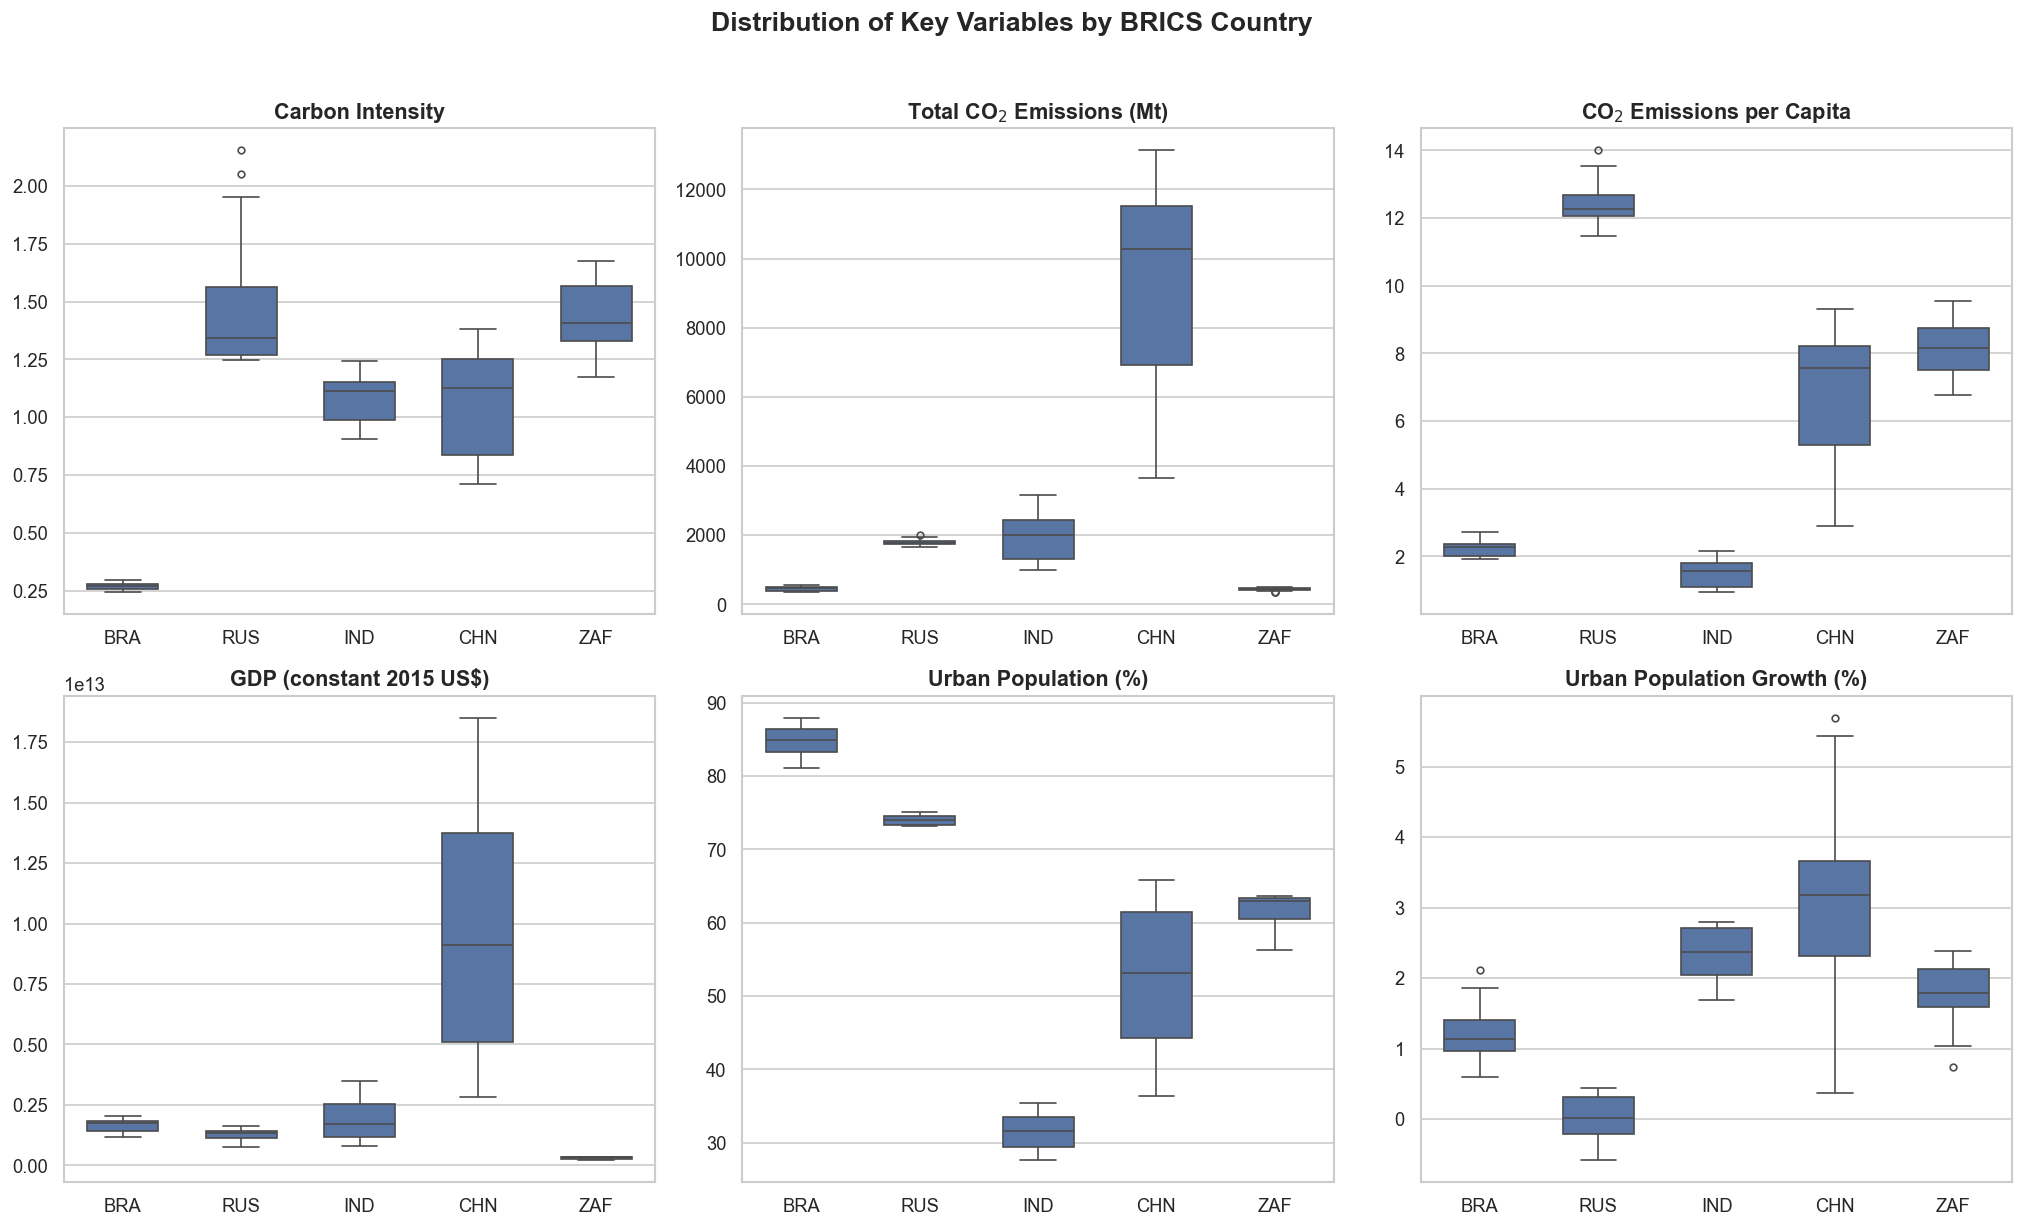

In [8]:
# Boxplot 
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

country_code_map = {
    "Brazil": "BRA",
    "Russian Federation": "RUS",
    "India": "IND",
    "China": "CHN",
    "South Africa": "ZAF"
}

df["country_short"] = df["country"].map(country_code_map)

# Check whether all country names were mapped correctly
if df["country_short"].isna().any():
    unmapped = df.loc[df["country_short"].isna(), "country"].unique()
    raise ValueError(f"Unmapped country names found: {unmapped}")

country_order = ["BRA", "RUS", "IND", "CHN", "ZAF"]

variables = {
    "carbon_intensity": "Carbon Intensity",
    "co2_total_mt": r"Total CO$_2$ Emissions (Mt)",
    "co2_per_capita": r"CO$_2$ Emissions per Capita",
    "gdp_constant_2015_usd": "GDP (constant 2015 US$)",
    "urban_population_pct": "Urban Population (%)",
    "urban_population_growth": "Urban Population Growth (%)"
}

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

for ax, (column, title) in zip(axes, variables.items()):
    sns.boxplot(
        data=df,
        x="country_short",
        y=column,
        order=country_order,
        width=0.6,
        linewidth=1,
        fliersize=4,
        ax=ax
    )

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=0)

    # Use scientific notation for GDP
    if column == "gdp_constant_2015_usd":
        ax.ticklabel_format(
            style="sci",
            axis="y",
            scilimits=(0, 0)
        )

fig.suptitle(
    "Distribution of Key Variables by BRICS Country",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

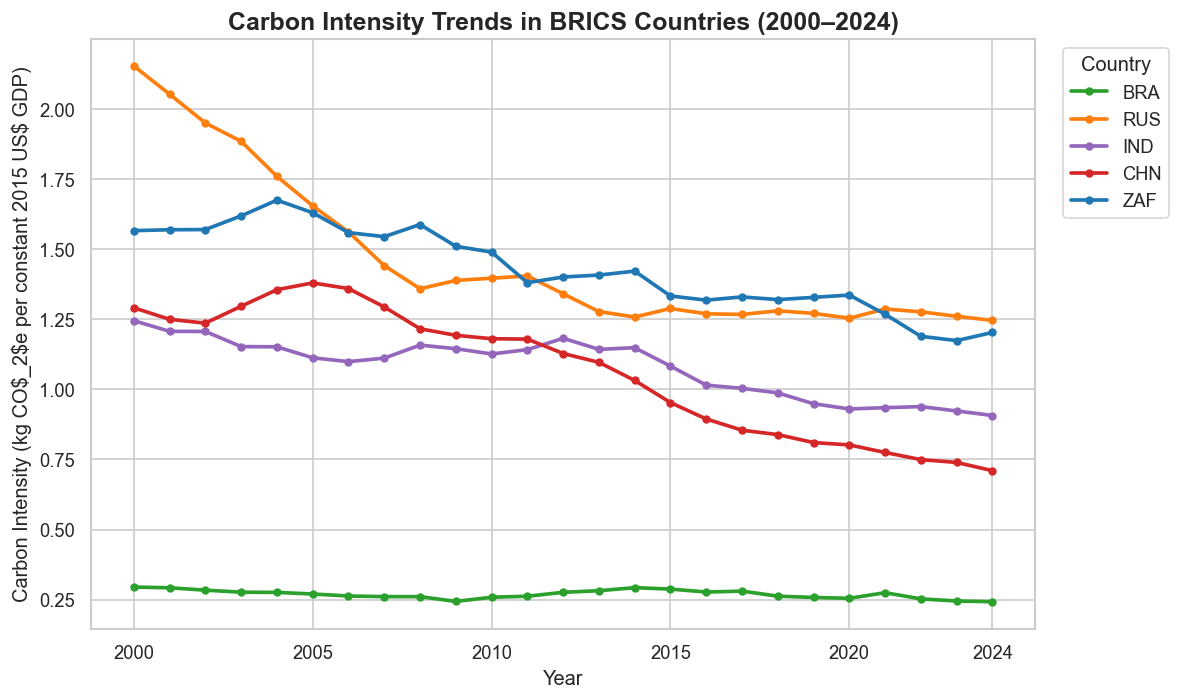

In [9]:
# trend

# Carbon Intensity

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 12

country_colors = {
    "Brazil": "#2CA02C",              # Green
    "Russian Federation": "#FF7F0E",  # Orange
    "India": "#9467BD",               # Purple
    "China": "#D62728",               # Red
    "South Africa": "#1F77B4"         # Blue
}

country_labels = {
    "Brazil": "BRA",
    "Russian Federation": "RUS",
    "India": "IND",
    "China": "CHN",
    "South Africa": "ZAF"
}

country_order = [
    "Brazil",
    "Russian Federation",
    "India",
    "China",
    "South Africa"
]

plt.figure(figsize=(10,6))

for country in country_order:

    subset = df[df["country"] == country]

    plt.plot(
        subset["Year"],
        subset["carbon_intensity"],
        marker="o",
        linewidth=2.2,
        markersize=4,
        color=country_colors[country],
        label=country_labels[country]
    )

plt.title(
    "Carbon Intensity Trends in BRICS Countries (2000–2024)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Carbon Intensity (kg CO$_2$e per constant 2015 US$ GDP)")

plt.xticks([2000, 2005, 2010, 2015, 2020, 2024])

plt.legend(
    title="Country",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True
)

plt.tight_layout()
plt.show()

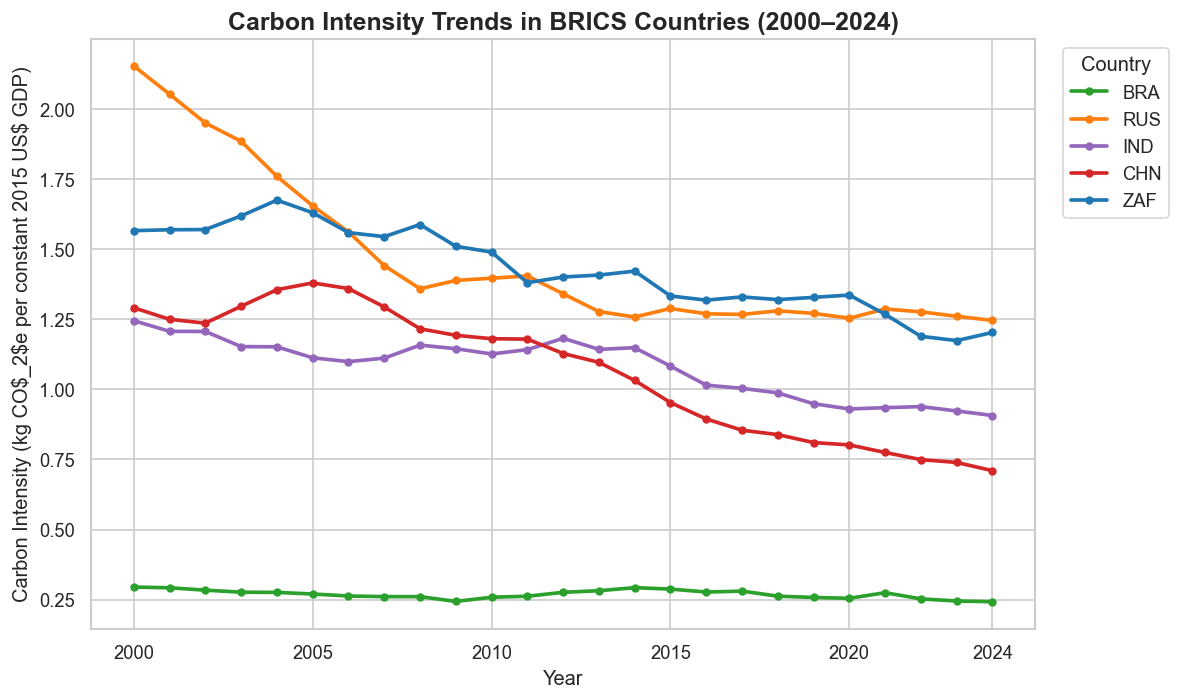

In [10]:
# trend

# Carbon Intensity

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 12

country_colors = {
    "Brazil": "#2CA02C",              # Green
    "Russian Federation": "#FF7F0E",  # Orange
    "India": "#9467BD",               # Purple
    "China": "#D62728",               # Red
    "South Africa": "#1F77B4"         # Blue
}

country_labels = {
    "Brazil": "BRA",
    "Russian Federation": "RUS",
    "India": "IND",
    "China": "CHN",
    "South Africa": "ZAF"
}

country_order = [
    "Brazil",
    "Russian Federation",
    "India",
    "China",
    "South Africa"
]

plt.figure(figsize=(10,6))

for country in country_order:

    subset = df[df["country"] == country]

    plt.plot(
        subset["Year"],
        subset["carbon_intensity"],
        marker="o",
        linewidth=2.2,
        markersize=4,
        color=country_colors[country],
        label=country_labels[country]
    )

plt.title(
    "Carbon Intensity Trends in BRICS Countries (2000–2024)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Carbon Intensity (kg CO$_2$e per constant 2015 US$ GDP)")

plt.xticks([2000, 2005, 2010, 2015, 2020, 2024])

plt.legend(
    title="Country",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True
)

plt.tight_layout()
plt.show()

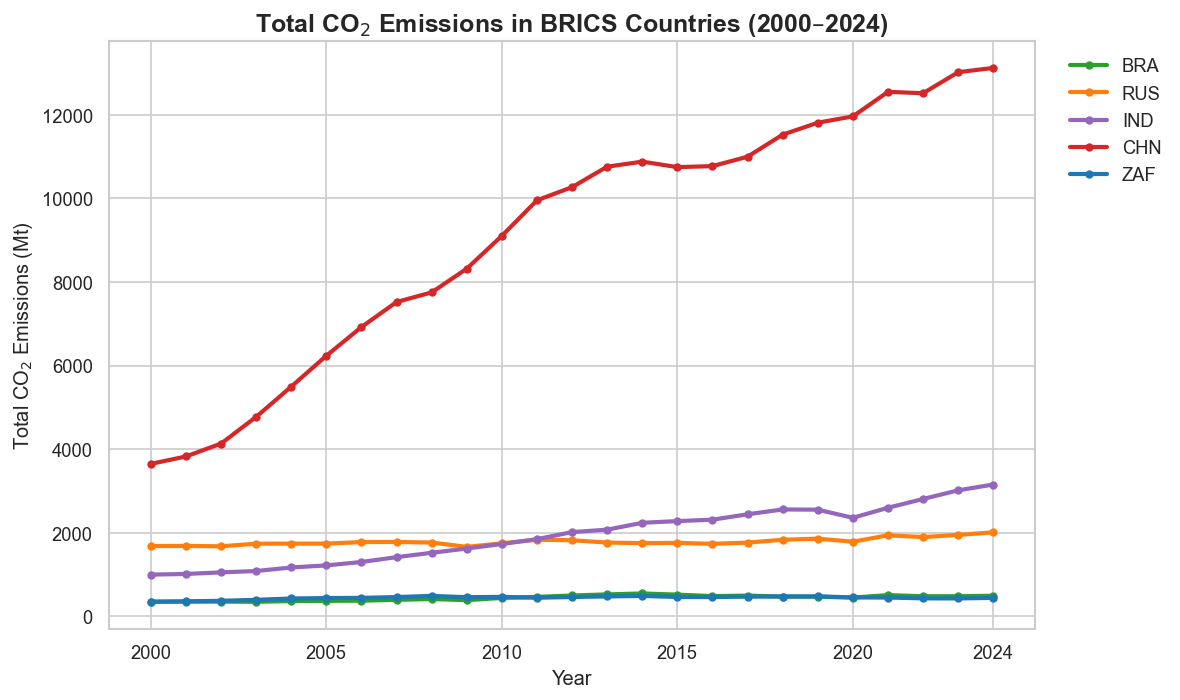

In [11]:
# Total CO₂ Emissions

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 12

country_colors = {
    "Brazil": "#2CA02C",
    "Russian Federation": "#FF7F0E",
    "India": "#9467BD",
    "China": "#D62728",
    "South Africa": "#1F77B4"
}

country_labels = {
    "Brazil": "BRA",
    "Russian Federation": "RUS",
    "India": "IND",
    "China": "CHN",
    "South Africa": "ZAF"
}

country_order = [
    "Brazil",
    "Russian Federation",
    "India",
    "China",
    "South Africa"
]

plt.figure(figsize=(10, 6))

for country in country_order:

    subset = df[df["country"] == country]

    plt.plot(
        subset["Year"],
        subset["co2_total_mt"],
        linewidth=2.5,
        marker="o",
        markersize=4,
        color=country_colors[country],
        label=country_labels[country]
    )

plt.title(
    "Total CO$_2$ Emissions in BRICS Countries (2000–2024)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Total CO$_2$ Emissions (Mt)")

plt.xticks([2000, 2005, 2010, 2015, 2020, 2024])

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()

plt.show()

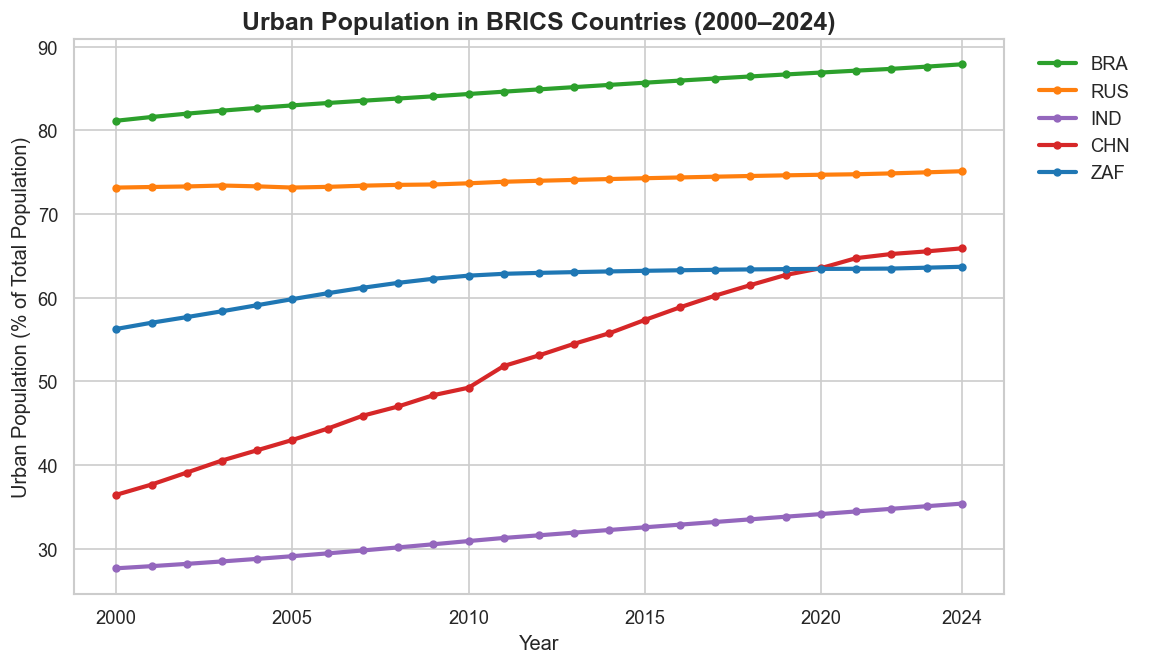

In [12]:
# Urban Population (%)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 12

country_colors = {
    "Brazil": "#2CA02C",
    "Russian Federation": "#FF7F0E",
    "India": "#9467BD",
    "China": "#D62728",
    "South Africa": "#1F77B4"
}

country_labels = {
    "Brazil": "BRA",
    "Russian Federation": "RUS",
    "India": "IND",
    "China": "CHN",
    "South Africa": "ZAF"
}

country_order = [
    "Brazil",
    "Russian Federation",
    "India",
    "China",
    "South Africa"
]

plt.figure(figsize=(10, 6))

for country in country_order:

    subset = df[df["country"] == country]

    plt.plot(
        subset["Year"],
        subset["urban_population_pct"],
        linewidth=2.5,
        marker="o",
        markersize=4,
        color=country_colors[country],
        label=country_labels[country]
    )

plt.title(
    "Urban Population in BRICS Countries (2000–2024)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Urban Population (% of Total Population)")

plt.xticks([2000, 2005, 2010, 2015, 2020, 2024])

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.show()

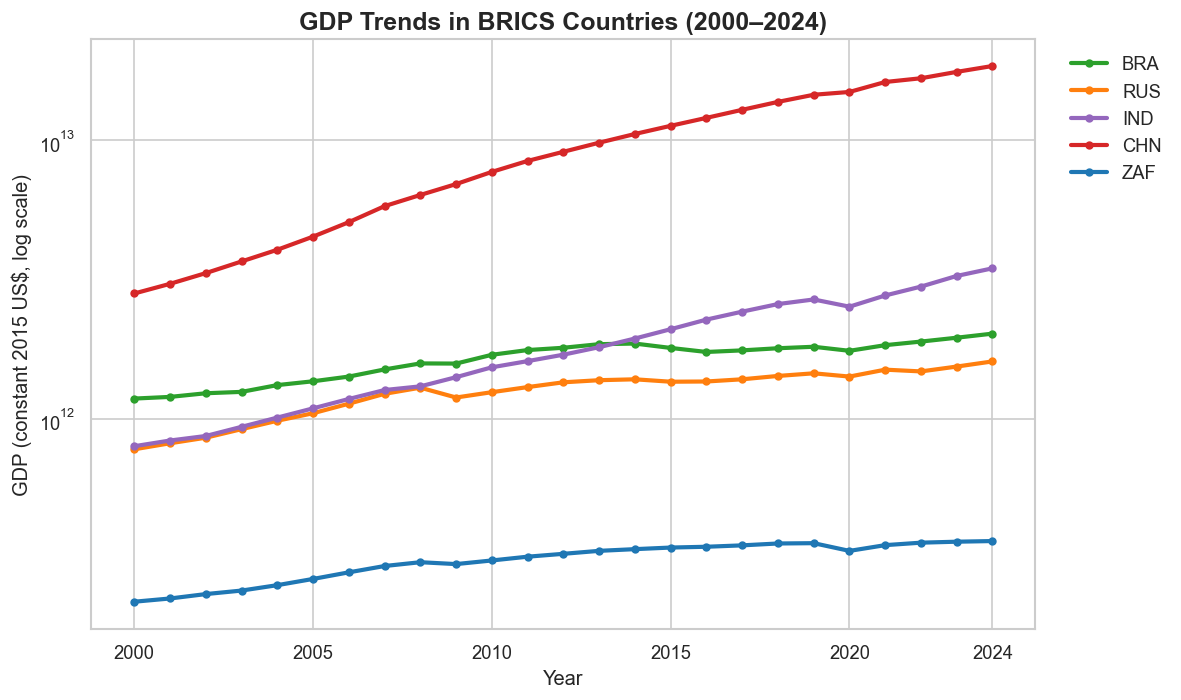

In [13]:
# GDP

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 12

country_colors = {
    "Brazil": "#2CA02C",
    "Russian Federation": "#FF7F0E",
    "India": "#9467BD",
    "China": "#D62728",
    "South Africa": "#1F77B4"
}

country_labels = {
    "Brazil": "BRA",
    "Russian Federation": "RUS",
    "India": "IND",
    "China": "CHN",
    "South Africa": "ZAF"
}

country_order = [
    "Brazil",
    "Russian Federation",
    "India",
    "China",
    "South Africa"
]

plt.figure(figsize=(10,6))

for country in country_order:

    subset = df[df["country"] == country]

    plt.plot(
        subset["Year"],
        subset["gdp_constant_2015_usd"],
        marker="o",
        linewidth=2.5,
        markersize=4,
        color=country_colors[country],
        label=country_labels[country]
    )

# log
plt.yscale("log")

plt.title(
    "GDP Trends in BRICS Countries (2000–2024)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("GDP (constant 2015 US$, log scale)")

plt.xticks([2000,2005,2010,2015,2020,2024])

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()

plt.show()

Variable,Carbon Intensity,Total CO$_2$ Emissions (Mt),CO$_2$ Emissions per Capita,GDP (constant 2015 US$),Urban Population (%),Urban Population Growth (%)
Variable,,,,,,
Carbon Intensity,1.000,-0.008,0.603,-0.194,-0.378,0.013
Total CO$_2$ Emissions (Mt),-0.008,1.000,0.166,0.960,-0.207,0.335
CO$_2$ Emissions per Capita,0.603,0.166,1.000,0.093,0.365,-0.499
GDP (constant 2015 US$),-0.194,0.960,0.093,1.000,-0.078,0.226
Urban Population (%),-0.378,-0.207,0.365,-0.078,1.000,-0.659
Urban Population Growth (%),0.013,0.335,-0.499,0.226,-0.659,1.000


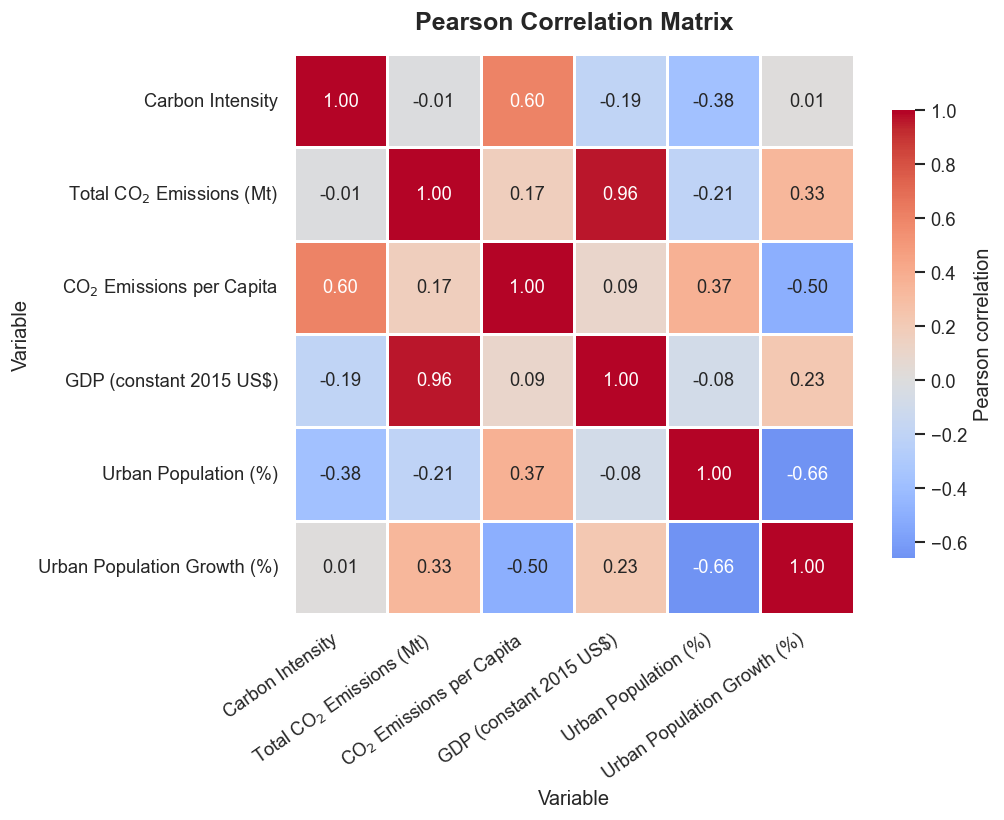

In [14]:
# heatmap
corr_vars = [
    "carbon_intensity",
    "co2_total_mt",
    "co2_per_capita",
    "gdp_constant_2015_usd",
    "urban_population_pct",
    "urban_population_growth"
]

corr_df = df[corr_vars].rename(columns={
    "carbon_intensity": "Carbon Intensity",
    "co2_total_mt": r"Total CO$_2$ Emissions (Mt)",
    "co2_per_capita": r"CO$_2$ Emissions per Capita",
    "gdp_constant_2015_usd": "GDP (constant 2015 US$)",
    "urban_population_pct": "Urban Population (%)",
    "urban_population_growth": "Urban Population Growth (%)"
})

corr = corr_df.corr(method="pearson")

display(corr.round(3))

sns.set_theme(style="white")

plt.figure(figsize=(9,7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.8,
    linecolor="white",
    annot_kws={
        "size":11
    },
    cbar_kws={
        "shrink":0.8,
        "label":"Pearson correlation"
    }
)

plt.title(
    "Pearson Correlation Matrix",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

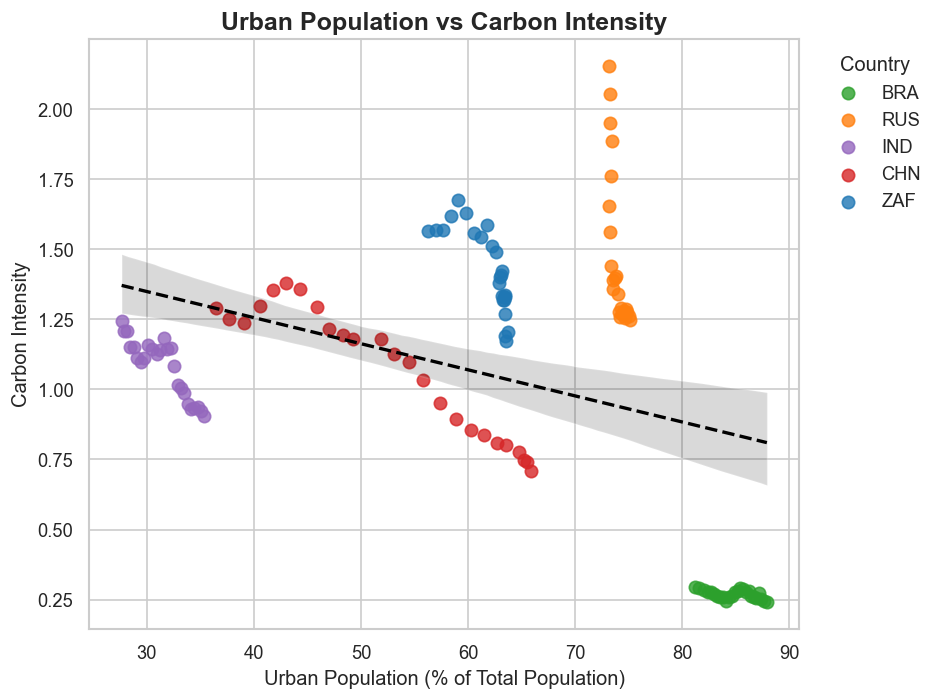

In [15]:
# scatter plot

# Urban Population (%) vs Carbon Intensity
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,6))

country_colors = {
    "Brazil": "#2CA02C",
    "Russian Federation": "#FF7F0E",
    "India": "#9467BD",
    "China": "#D62728",
    "South Africa": "#1F77B4"
}

country_labels = {
    "Brazil": "BRA",
    "Russian Federation": "RUS",
    "India": "IND",
    "China": "CHN",
    "South Africa": "ZAF"
}

for country in country_colors.keys():

    subset = df[df["country"] == country]

    plt.scatter(
        subset["urban_population_pct"],
        subset["carbon_intensity"],
        s=55,
        alpha=0.8,
        color=country_colors[country],
        label=country_labels[country]
    )

# Overall regression line
sns.regplot(
    data=df,
    x="urban_population_pct",
    y="carbon_intensity",
    scatter=False,
    color="black",
    line_kws={
        "linestyle":"--",
        "linewidth":2
    }
)

plt.title(
    "Urban Population vs Carbon Intensity",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Urban Population (% of Total Population)")
plt.ylabel("Carbon Intensity")

plt.legend(
    title="Country",
    frameon=False,
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

# RQ1: Descriptive and trend analysis

In [16]:
country_labels = {
    "Brazil": "BRA",
    "Russian Federation": "RUS",
    "India": "IND",
    "China": "CHN",
    "South Africa": "ZAF"
}

df["country_code"] = df["country"].map(country_labels)

print(df[["country", "country_code"]].drop_duplicates())

Variable             country country_code
0                     Brazil          BRA
25                     China          CHN
50                     India          IND
75        Russian Federation          RUS
100             South Africa          ZAF


In [17]:
# Baseline and endpoint comparison

baseline_year = 2000
end_year = 2024

selected_vars = [
    "carbon_intensity",
    "co2_total_mt",
    "co2_per_capita",
    "gdp_constant_2015_usd",
    "urban_population_pct"
]

start_values = (
    df[df["Year"] == baseline_year]
    .set_index("country_code")[selected_vars]
)

end_values = (
    df[df["Year"] == end_year]
    .set_index("country_code")[selected_vars]
)

baseline_endpoint = pd.concat(
    {
        str(baseline_year): start_values,
        str(end_year): end_values
    },
    axis=1
)

display(baseline_endpoint.round(3))

2000                              \
Variable     carbon_intensity co2_total_mt co2_per_capita   
country_code                                                
BRA                     0.295      349.408          2.008   
CHN                     1.291     3647.877          2.889   
IND                     1.245      996.891          0.942   
RUS                     2.154     1681.152         11.468   
ZAF                     1.567      347.283          7.364   

                                                                    2024  \
Variable     gdp_constant_2015_usd urban_population_pct carbon_intensity   
country_code                                                               
BRA              1186418964121.030               81.148            0.242   
CHN              2825096197799.540               36.432            0.710   
IND               800534479623.610               27.647            0.907   
RUS               780432873752.842               73.157            1.246   
ZAF               221691970228.101               56.259            1.203   

                                                                \
Variable     co2_total_mt co2_per_capita gdp_constant_2015_usd   
country_code                                                     
BRA               491.469          2.318     2028136094548.340   
CHN             13124.728          9.315    18488114837769.301   
IND              3153.829          2.174     3477820532826.480   
RUS              2009.154         13.998     1612344875264.360   
ZAF               440.168          6.877      365831497261.341   

                                   
Variable     urban_population_pct  
country_code                       
BRA                        87.896  
CHN                        65.895  
IND                        35.379  
RUS                        75.112  
ZAF                        63.692

In [18]:
# Absolute and percentage changes, 2000–2024

absolute_change = end_values - start_values

percentage_change = (
    (end_values - start_values)
    / start_values
    * 100
)

absolute_change.columns = [
    f"{col}_absolute_change"
    for col in absolute_change.columns
]

percentage_change.columns = [
    f"{col}_pct_change"
    for col in percentage_change.columns
]

change_summary = pd.concat(
    [absolute_change, percentage_change],
    axis=1
)

change_summary.index.name = "Country"

display(change_summary.round(2))

,carbon_intensity_absolute_change,co2_total_mt_absolute_change,co2_per_capita_absolute_change,gdp_constant_2015_usd_absolute_change,urban_population_pct_absolute_change,carbon_intensity_pct_change,co2_total_mt_pct_change,co2_per_capita_pct_change,gdp_constant_2015_usd_pct_change,urban_population_pct_pct_change
Country,,,,,,,,,,
BRA,-0.050,142.060,0.310,841717130427.310,6.750,-17.720,40.660,15.460,70.950,8.310
CHN,-0.580,9476.850,6.430,15663018639969.760,29.460,-45.020,259.790,222.420,554.420,80.870
IND,-0.340,2156.940,1.230,2677286053202.870,7.730,-27.180,216.370,130.670,334.440,27.970
RUS,-0.910,328.000,2.530,831912001511.520,1.960,-42.150,19.510,22.060,106.600,2.670
ZAF,-0.360,92.880,-0.490,144139527033.240,7.430,-23.190,26.750,-6.620,65.020,13.210


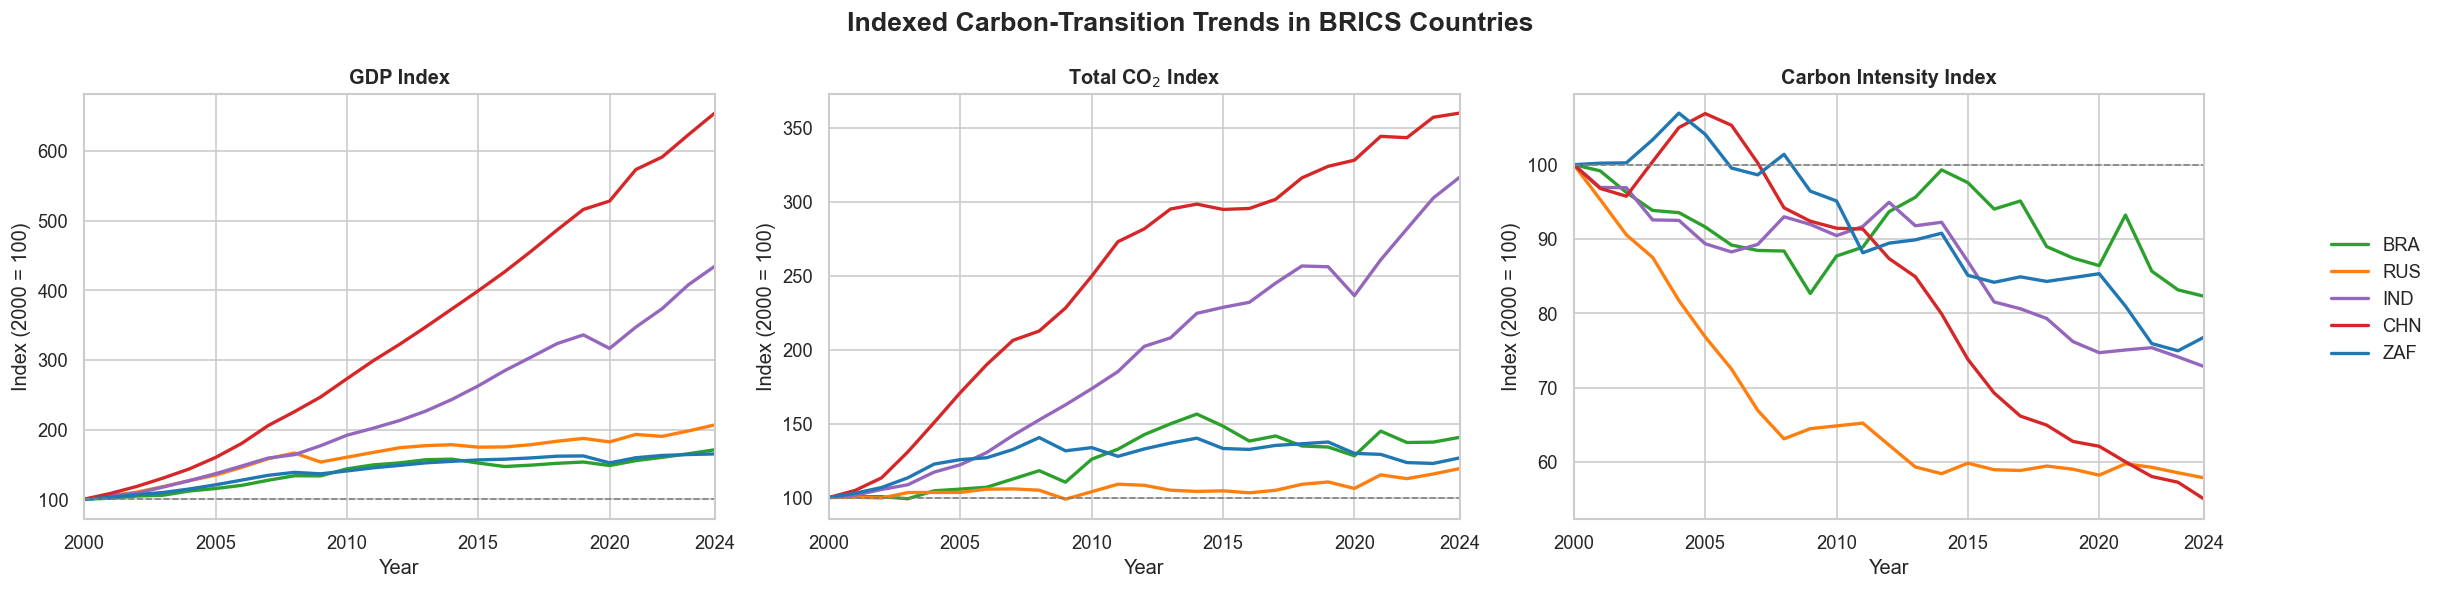

In [19]:
# Indexed trends: 2000 = 100

indexed_vars = [
    "gdp_constant_2015_usd",
    "co2_total_mt",
    "carbon_intensity"
]

indexed_df = df[
    ["country", "Year"] + indexed_vars
].copy()

for variable in indexed_vars:
    indexed_df[f"{variable}_index"] = (
        indexed_df.groupby("country")[variable]
        .transform(lambda x: x / x.iloc[0] * 100)
    )

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 5),
    sharex=True
)

indexed_titles = {
    "gdp_constant_2015_usd_index": "GDP Index",
    "co2_total_mt_index": r"Total CO$_2$ Index",
    "carbon_intensity_index": "Carbon Intensity Index"
}

for ax, (variable, title) in zip(
    axes,
    indexed_titles.items()
):
    for country in country_order:
        subset = indexed_df[
            indexed_df["country"] == country
        ]

        ax.plot(
            subset["Year"],
            subset[variable],
            color=country_colors[country],
            label=country_labels[country],
            linewidth=2
        )

    ax.axhline(
        100,
        color="grey",
        linestyle="--",
        linewidth=1
    )

    ax.set_xlim(2000, 2024)
    ax.set_xticks([2000, 2005, 2010, 2015, 2020, 2024])
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Index (2000 = 100)")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center right",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

fig.suptitle(
    "Indexed Carbon-Transition Trends in BRICS Countries",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 0.94, 1])
plt.show()

In [20]:
# CAGR

number_of_years = end_year - baseline_year

cagr_vars = [
    "carbon_intensity",
    "co2_total_mt",
    "co2_per_capita",
    "gdp_constant_2015_usd"
]

cagr_results = pd.DataFrame(index=start_values.index)

for variable in cagr_vars:
    cagr_results[f"{variable}_CAGR_pct"] = (
        (
            end_values[variable]
            / start_values[variable]
        ) ** (1 / number_of_years)
        - 1
    ) * 100

cagr_results.index.name = "Country"
cagr_results = cagr_results.reset_index()

display(cagr_results.round(3))

,Country,carbon_intensity_CAGR_pct,co2_total_mt_CAGR_pct,co2_per_capita_CAGR_pct,gdp_constant_2015_usd_CAGR_pct
0,BRA,-0.809,1.432,0.601,2.259
1,CHN,-2.462,5.480,4.999,8.142
2,IND,-1.313,4.916,3.544,6.312
3,RUS,-2.255,0.745,0.834,3.069
4,ZAF,-1.093,0.992,-0.285,2.109


# RQ2: Fixed-effects regression (M1–M4)

In [22]:
import numpy as np
import pandas as pd

rq2_df = df.copy()

# Sort panel
rq2_df = rq2_df.sort_values(
    ["country", "Year"]
).reset_index(drop=True)

# Log-transform positive outcome/control variables
rq2_df["ln_co2_total"] = np.log(
    rq2_df["co2_total_mt"]
)

rq2_df["ln_co2_per_capita"] = np.log(
    rq2_df["co2_per_capita"]
)

rq2_df["ln_carbon_intensity"] = np.log(
    rq2_df["carbon_intensity"]
)

rq2_df["ln_gdp"] = np.log(
    rq2_df["gdp_constant_2015_usd"]
)

# Variables required for RQ2
rq2_vars = [
    "urban_population_pct",
    "urban_population_growth",
    "ln_co2_total",
    "ln_co2_per_capita",
    "ln_carbon_intensity",
    "ln_gdp"
]

# Check missing/infinite values
print(rq2_df[rq2_vars].isna().sum())

print(
    np.isinf(
        rq2_df[rq2_vars]
    ).sum()
)

Variable
urban_population_pct       0
urban_population_growth    0
ln_co2_total               0
ln_co2_per_capita          0
ln_carbon_intensity        0
ln_gdp                     0
dtype: int64
Variable
urban_population_pct       0
urban_population_growth    0
ln_co2_total               0
ln_co2_per_capita          0
ln_carbon_intensity        0
ln_gdp                     0
dtype: int64


In [23]:
# Within-country variation

within_summary = (
    rq2_df
    .groupby("country_short")
    .agg(
        urban_mean=("urban_population_pct", "mean"),
        urban_std=("urban_population_pct", "std"),
        urban_min=("urban_population_pct", "min"),
        urban_max=("urban_population_pct", "max"),
        urban_change=(
            "urban_population_pct",
            lambda x: x.iloc[-1] - x.iloc[0]
        )
    )
    .round(3)
)

within_summary.index.name = "Country"

display(within_summary)

,urban_mean,urban_std,urban_min,urban_max,urban_change
Country,,,,,
BRA,84.791,1.997,81.148,87.896,6.747
CHN,52.557,9.750,36.432,65.895,29.463
IND,31.501,2.428,27.647,35.379,7.732
RUS,73.984,0.646,73.157,75.112,1.955
ZAF,61.714,2.317,56.259,63.692,7.433


In [24]:
# Pearson and Spearman correlations

corr_vars = [
    "urban_population_pct",
    "ln_gdp",
    "ln_co2_total",
    "ln_co2_per_capita",
    "ln_carbon_intensity"
]

pearson_corr = (
    rq2_df[corr_vars]
    .corr(method="pearson")
    .round(3)
)

spearman_corr = (
    rq2_df[corr_vars]
    .corr(method="spearman")
    .round(3)
)

print("Pearson correlation")
display(pearson_corr)

print("Spearman correlation")
display(spearman_corr)

Pearson correlation


Variable,urban_population_pct,ln_gdp,ln_co2_total,ln_co2_per_capita,ln_carbon_intensity
Variable,,,,,
urban_population_pct,1.000,-0.117,-0.407,0.401,-0.518
ln_gdp,-0.117,1.000,0.836,-0.086,-0.241
ln_co2_total,-0.407,0.836,1.000,0.203,0.330
ln_co2_per_capita,0.401,-0.086,0.203,1.000,0.508
ln_carbon_intensity,-0.518,-0.241,0.330,0.508,1.000


Spearman correlation


Variable,urban_population_pct,ln_gdp,ln_co2_total,ln_co2_per_capita,ln_carbon_intensity
Variable,,,,,
urban_population_pct,1.000,-0.053,-0.387,0.384,-0.280
ln_gdp,-0.053,1.000,0.766,-0.184,-0.589
ln_co2_total,-0.387,0.766,1.000,0.158,-0.022
ln_co2_per_capita,0.384,-0.184,0.158,1.000,0.582
ln_carbon_intensity,-0.280,-0.589,-0.022,0.582,1.000


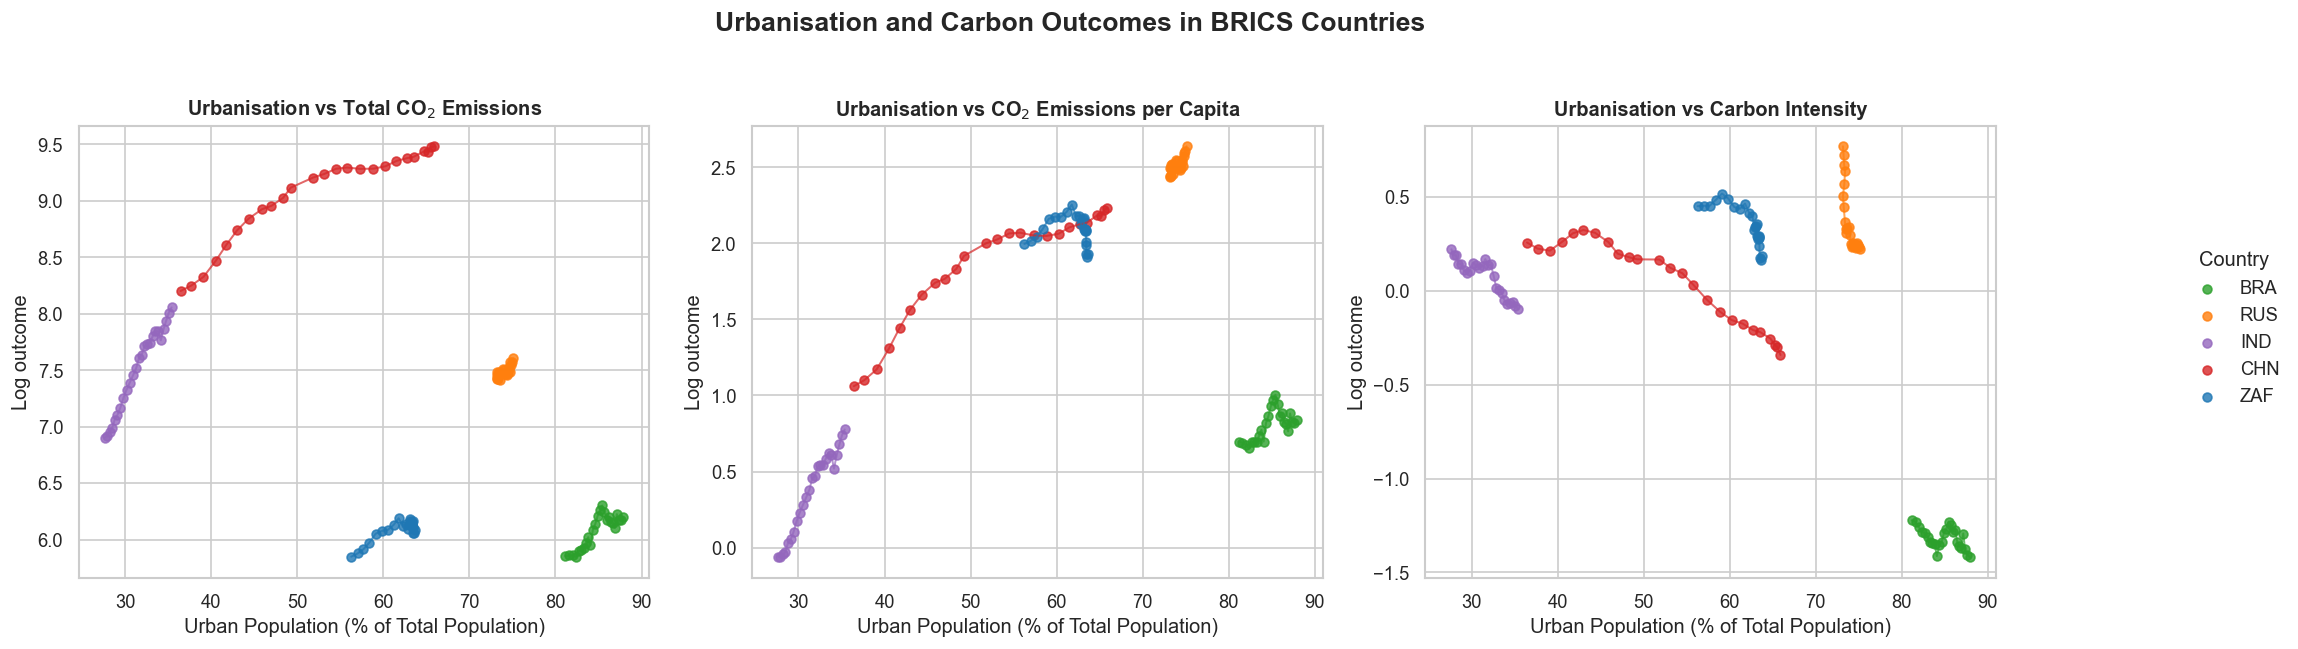

In [25]:
# Country-specific urbanisation trajectories

import matplotlib.pyplot as plt

scatter_outcomes = {
    "ln_co2_total":
        r"Urbanisation vs Total CO$_2$ Emissions",

    "ln_co2_per_capita":
        r"Urbanisation vs CO$_2$ Emissions per Capita",

    "ln_carbon_intensity":
        "Urbanisation vs Carbon Intensity"
}

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.5)
)

for ax, (outcome, title) in zip(
    axes,
    scatter_outcomes.items()
):
    for country in country_order:

        subset = (
            rq2_df[
                rq2_df["country"] == country
            ]
            .sort_values("Year")
        )

        ax.plot(
            subset["urban_population_pct"],
            subset[outcome],
            linewidth=1.2,
            alpha=0.7,
            color=country_colors[country]
        )

        ax.scatter(
            subset["urban_population_pct"],
            subset[outcome],
            s=28,
            alpha=0.8,
            color=country_colors[country],
            label=country_labels[country]
        )

    ax.set_title(
        title,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Urban Population (% of Total Population)"
    )

    ax.set_ylabel("Log outcome")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Country",
    bbox_to_anchor=(1.01, 0.5),
    loc="center left",
    frameon=False
)

fig.suptitle(
    "Urbanisation and Carbon Outcomes in BRICS Countries",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 0.94, 0.95]
)

plt.show()

In [26]:
# Set panel index

panel_rq2 = (
    rq2_df
    .set_index(
        ["country_short", "Year"]
    )
    .sort_index()
)

print(panel_rq2.index.names)
print(panel_rq2.shape)

display(panel_rq2.head())

['country_short', 'Year']
(125, 12)


Variable           country country_code  carbon_intensity  co2_per_capita  \
country_short Year                                                          
BRA           2000  Brazil          BRA             0.295           2.008   
              2001  Brazil          BRA             0.292           1.993   
              2002  Brazil          BRA             0.283           1.969   
              2003  Brazil          BRA             0.276           1.918   
              2004  Brazil          BRA             0.275           2.000   

Variable            co2_total_mt  gdp_constant_2015_usd  \
country_short Year                                        
BRA           2000       349.408      1186418964121.030   
              2001       351.337      1202908958645.150   
              2002       351.437      1239639324869.850   
              2003       346.505      1253781489768.130   
              2004       365.311      1325998860202.270   

Variable            urban_population_growth  urban_population_pct  \
country_short Year                                                  
BRA           2000                    2.120                81.148   
              2001                    1.853                81.596   
              2002                    1.728                81.994   
              2003                    1.618                82.354   
              2004                    1.527                82.682   

Variable            ln_co2_total  ln_co2_per_capita  ln_carbon_intensity  \
country_short Year                                                         
BRA           2000         5.856              0.697               -1.222   
              2001         5.862              0.690               -1.231   
              2002         5.862              0.677               -1.261   
              2003         5.848              0.651               -1.286   
              2004         5.901              0.693               -1.289   

Variable            ln_gdp  
country_short Year          
BRA           2000  27.802  
              2001  27.816  
              2002  27.846  
              2003  27.857  
              2004  27.913

In [29]:
!pip install linearmodels

In [28]:
from linearmodels.panel import PanelOLS

In [30]:
# RQ2 Model 1
# Urbanisation -> Total CO2
# Country FE + Year FE

model1 = PanelOLS.from_formula(
    """
    ln_co2_total
    ~ 1
    + urban_population_pct
    + EntityEffects
    + TimeEffects
    """,
    data=panel_rq2
)

res1 = model1.fit(
    cov_type="robust"
)

print(res1.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:           ln_co2_total   R-squared:                        0.4429
Estimator:                   PanelOLS   R-squared (Between):             -0.8160
No. Observations:                 125   R-squared (Within):               0.6403
Date:                Tue, Aug 25 2026   R-squared (Overall):             -0.7434
Time:                        21:14:51   Log-likelihood                    89.869
Cov. Estimator:                Robust                                           
                                        F-statistic:                      75.527
Entities:                           5   P-value                           0.0000
Avg Obs:                       25.000   Distribution:                    F(1,95)
Min Obs:                       25.000                                           
Max Obs:                       25.000   F-statistic (robust):             112.17
                            

In [31]:
# RQ2 Model 2
# Urbanisation -> Total CO2
# controlling for GDP

model2 = PanelOLS.from_formula(
    """
    ln_co2_total
    ~ 1
    + urban_population_pct
    + ln_gdp
    + EntityEffects
    + TimeEffects
    """,
    data=panel_rq2
)

res2 = model2.fit(
    cov_type="robust"
)

print(res2.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:           ln_co2_total   R-squared:                        0.7940
Estimator:                   PanelOLS   R-squared (Between):              0.7494
No. Observations:                 125   R-squared (Within):               0.8694
Date:                Tue, Aug 25 2026   R-squared (Overall):              0.7554
Time:                        21:15:00   Log-likelihood                    152.06
Cov. Estimator:                Robust                                           
                                        F-statistic:                      181.19
Entities:                           5   P-value                           0.0000
Avg Obs:                       25.000   Distribution:                    F(2,94)
Min Obs:                       25.000                                           
Max Obs:                       25.000   F-statistic (robust):             247.00
                            

In [32]:
# RQ2 Model 3
# Urbanisation -> CO2 per capita

model3 = PanelOLS.from_formula(
    """
    ln_co2_per_capita
    ~ 1
    + urban_population_pct
    + EntityEffects
    + TimeEffects
    """,
    data=panel_rq2
)

res3 = model3.fit(
    cov_type="robust"
)

print(res3.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:      ln_co2_per_capita   R-squared:                        0.5010
Estimator:                   PanelOLS   R-squared (Between):             -0.0192
No. Observations:                 125   R-squared (Within):               0.6666
Date:                Tue, Aug 25 2026   R-squared (Overall):              0.0244
Time:                        21:15:07   Log-likelihood                    99.470
Cov. Estimator:                Robust                                           
                                        F-statistic:                      95.365
Entities:                           5   P-value                           0.0000
Avg Obs:                       25.000   Distribution:                    F(1,95)
Min Obs:                       25.000                                           
Max Obs:                       25.000   F-statistic (robust):             141.31
                            

In [33]:
# RQ2 Model 4
# Urbanisation -> Carbon intensity

model4 = PanelOLS.from_formula(
    """
    ln_carbon_intensity
    ~ 1
    + urban_population_pct
    + EntityEffects
    + TimeEffects
    """,
    data=panel_rq2
)

res4 = model4.fit(
    cov_type="robust"
)

print(res4.summary)

                           PanelOLS Estimation Summary                           
Dep. Variable:     ln_carbon_intensity   R-squared:                        0.2300
Estimator:                    PanelOLS   R-squared (Between):              0.2348
No. Observations:                  125   R-squared (Within):               0.4585
Date:                 Tue, Aug 25 2026   R-squared (Overall):              0.2458
Time:                         21:15:15   Log-likelihood                    149.83
Cov. Estimator:                 Robust                                           
                                         F-statistic:                      28.381
Entities:                            5   P-value                           0.0000
Avg Obs:                        25.000   Distribution:                    F(1,95)
Min Obs:                        25.000                                           
Max Obs:                        25.000   F-statistic (robust):             19.090
                

In [34]:
# Summary regression table

results = {
    "M1: Total CO2":
        res1,
    "M2: Total CO2 + GDP":
        res2,
    "M3: CO2 per capita":
        res3,
    "M4: Carbon intensity":
        res4
}

rows = []

for model_name, result in results.items():

    for variable in [
        "urban_population_pct",
        "ln_gdp"
    ]:

        if variable in result.params.index:

            rows.append({
                "Model": model_name,
                "Variable": variable,
                "Coefficient":
                    result.params[variable],
                "Std. Error":
                    result.std_errors[variable],
                "t-stat":
                    result.tstats[variable],
                "p-value":
                    result.pvalues[variable],
                "Within R2":
                    result.rsquared_within
            })

regression_summary = (
    pd.DataFrame(rows)
    .round(4)
)

display(regression_summary)

,Model,Variable,Coefficient,Std. Error,t-stat,p-value,Within R2
0,M1: Total CO2,urban_population_pct,0.033,0.003,10.591,0.000,0.640
1,M2: Total CO2 + GDP,urban_population_pct,-0.007,0.004,-1.516,0.133,0.869
2,M2: Total CO2 + GDP,ln_gdp,0.873,0.059,14.877,0.000,0.869
3,M3: CO2 per capita,urban_population_pct,0.034,0.003,11.887,0.000,0.667
4,M4: Carbon intensity,urban_population_pct,-0.012,0.003,-4.369,0.000,0.459


In [35]:
# Robustness: Driscoll–Kraay Standard Errors

# Model 1: Urbanisation -> Total CO2
res1_dk = model1.fit(
    cov_type="kernel",
    kernel="bartlett"
)

# Model 2: Urbanisation -> Total CO2, controlling for GDP
res2_dk = model2.fit(
    cov_type="kernel",
    kernel="bartlett"
)

# Model 3: Urbanisation -> CO2 per capita
res3_dk = model3.fit(
    cov_type="kernel",
    kernel="bartlett"
)

# Model 4: Urbanisation -> Carbon intensity
res4_dk = model4.fit(
    cov_type="kernel",
    kernel="bartlett"
)

print("MODEL 1 — Driscoll-Kraay")
print(res1_dk.summary)

print("\nMODEL 2 — Driscoll-Kraay")
print(res2_dk.summary)

print("\nMODEL 3 — Driscoll-Kraay")
print(res3_dk.summary)

print("\nMODEL 4 — Driscoll-Kraay")
print(res4_dk.summary)

MODEL 1 — Driscoll-Kraay
                          PanelOLS Estimation Summary                           
Dep. Variable:           ln_co2_total   R-squared:                        0.4429
Estimator:                   PanelOLS   R-squared (Between):             -0.8160
No. Observations:                 125   R-squared (Within):               0.6403
Date:                Tue, Aug 25 2026   R-squared (Overall):             -0.7434
Time:                        21:15:35   Log-likelihood                    89.869
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      75.527
Entities:                           5   P-value                           0.0000
Avg Obs:                       25.000   Distribution:                    F(1,95)
Min Obs:                       25.000                                           
Max Obs:                       25.000   F-statistic (robust):             54.915
   

In [36]:
# Compare Robust SE vs Driscoll–Kraay SE

model_pairs = {
    "M1: Total CO2": (res1, res1_dk),
    "M2: Total CO2 + GDP": (res2, res2_dk),
    "M3: CO2 per capita": (res3, res3_dk),
    "M4: Carbon intensity": (res4, res4_dk)
}

comparison_rows = []

for model_name, (robust_res, dk_res) in model_pairs.items():

    for variable in ["urban_population_pct", "ln_gdp"]:

        if variable in robust_res.params.index:

            comparison_rows.append({
                "Model": model_name,
                "Variable": variable,

                "Coefficient":
                    robust_res.params[variable],

                "Robust SE":
                    robust_res.std_errors[variable],

                "Robust p-value":
                    robust_res.pvalues[variable],

                "DK SE":
                    dk_res.std_errors[variable],

                "DK p-value":
                    dk_res.pvalues[variable]
            })

comparison_table = pd.DataFrame(
    comparison_rows
).round(4)

display(comparison_table)

,Model,Variable,Coefficient,Robust SE,Robust p-value,DK SE,DK p-value
0,M1: Total CO2,urban_population_pct,0.033,0.003,0.000,0.004,0.000
1,M2: Total CO2 + GDP,urban_population_pct,-0.007,0.004,0.133,0.007,0.344
2,M2: Total CO2 + GDP,ln_gdp,0.873,0.059,0.000,0.059,0.000
3,M3: CO2 per capita,urban_population_pct,0.034,0.003,0.000,0.004,0.000
4,M4: Carbon intensity,urban_population_pct,-0.012,0.003,0.000,0.005,0.013


In [37]:
# Significance comparison

comparison_table["Robust Sig."] = comparison_table[
    "Robust p-value"
].apply(
    lambda p: "***" if p < 0.01
    else "**" if p < 0.05
    else "*" if p < 0.10
    else "n.s."
)

comparison_table["DK Sig."] = comparison_table[
    "DK p-value"
].apply(
    lambda p: "***" if p < 0.01
    else "**" if p < 0.05
    else "*" if p < 0.10
    else "n.s."
)

comparison_table["Inference Changed?"] = (
    comparison_table["Robust Sig."]
    == comparison_table["DK Sig."]
)

display(comparison_table)

,Model,Variable,Coefficient,Robust SE,Robust p-value,DK SE,DK p-value,Robust Sig.,DK Sig.,Inference Changed?
0,M1: Total CO2,urban_population_pct,0.033,0.003,0.000,0.004,0.000,***,***,True
1,M2: Total CO2 + GDP,urban_population_pct,-0.007,0.004,0.133,0.007,0.344,n.s.,n.s.,True
2,M2: Total CO2 + GDP,ln_gdp,0.873,0.059,0.000,0.059,0.000,***,***,True
3,M3: CO2 per capita,urban_population_pct,0.034,0.003,0.000,0.004,0.000,***,***,True
4,M4: Carbon intensity,urban_population_pct,-0.012,0.003,0.000,0.005,0.013,***,**,False


# RQ3: Tapio decoupling analysis

In [38]:
# Prepare data

rq3 = df.copy()

rq3 = rq3.sort_values(
    ["country", "Year"]
).reset_index(drop=True)

# Keep the variables needed for RQ3
rq3_vars = [
    "country",
    "country_code",
    "Year",
    "gdp_constant_2015_usd",
    "co2_total_mt",
    "carbon_intensity",
    "urban_population_pct"
]

rq3 = rq3[rq3_vars].copy()

display(rq3.head())

Variable,country,country_code,Year,gdp_constant_2015_usd,co2_total_mt,carbon_intensity,urban_population_pct
0,Brazil,BRA,2000,1186418964121.030,349.408,0.295,81.148
1,Brazil,BRA,2001,1202908958645.150,351.337,0.292,81.596
2,Brazil,BRA,2002,1239639324869.850,351.437,0.283,81.994
3,Brazil,BRA,2003,1253781489768.130,346.505,0.276,82.354
4,Brazil,BRA,2004,1325998860202.270,365.311,0.275,82.682


In [39]:
# Annual percentage changes and Tapio elasticity

# Make sure observations are ordered correctly
rq3 = rq3.sort_values(["country", "Year"]).copy()

# Annual proportional change in GDP
rq3["gdp_growth"] = (
    rq3.groupby("country")["gdp_constant_2015_usd"]
       .pct_change(fill_method=None)
)

# Annual proportional change in CO2 emissions
rq3["co2_growth"] = (
    rq3.groupby("country")["co2_total_mt"]
       .pct_change(fill_method=None)
)

# Tapio decoupling elasticity
rq3["tapio_elasticity"] = (
    rq3["co2_growth"] / rq3["gdp_growth"]
)

# Check results
display(
    rq3[
        [
            "country_code",
            "Year",
            "gdp_growth",
            "co2_growth",
            "tapio_elasticity"
        ]
    ].head(10)
)

Variable,country_code,Year,gdp_growth,co2_growth,tapio_elasticity
0,BRA,2000,NaN,NaN,NaN
1,BRA,2001,0.014,0.006,0.397
2,BRA,2002,0.031,0.000,0.009
3,BRA,2003,0.011,-0.014,-1.230
4,BRA,2004,0.058,0.054,0.942
5,BRA,2005,0.032,0.011,0.337
6,BRA,2006,0.040,0.012,0.303
7,BRA,2007,0.061,0.052,0.857
8,BRA,2008,0.051,0.050,0.982
9,BRA,2009,-0.001,-0.066,52.370


In [40]:
# Tapio classification

def classify_tapio(row):

    g = row["gdp_growth"]
    c = row["co2_growth"]
    e = row["tapio_elasticity"]

    if pd.isna(g) or pd.isna(c) or pd.isna(e):
        return np.nan

    # Economic expansion
    if g > 0:

        if c < 0:
            return "Strong Decoupling"

        elif 0 <= e < 0.8:
            return "Weak Decoupling"

        elif 0.8 <= e <= 1.2:
            return "Expansive Coupling"

        else:
            return "Expansive Negative Decoupling"

    # Economic contraction
    else:

        if c < 0:

            if e > 1.2:
                return "Recessive Decoupling"

            elif 0.8 <= e <= 1.2:
                return "Recessive Coupling"

            else:
                return "Weak Negative Decoupling"

        else:
            return "Strong Negative Decoupling"


rq3["tapio_category"] = rq3.apply(
    classify_tapio,
    axis=1
)

display(
    rq3[
        [
            "country_code",
            "Year",
            "tapio_elasticity",
            "tapio_category"
        ]
    ].dropna().head(120)
)

Variable,country_code,Year,tapio_elasticity,tapio_category
1,BRA,2001,0.397,Weak Decoupling
2,BRA,2002,0.009,Weak Decoupling
3,BRA,2003,-1.230,Strong Decoupling
4,BRA,2004,0.942,Expansive Coupling
5,BRA,2005,0.337,Weak Decoupling
...,...,...,...,...
120,ZAF,2020,0.906,Recessive Coupling
121,ZAF,2021,-0.105,Strong Decoupling
122,ZAF,2022,-2.084,Strong Decoupling
123,ZAF,2023,-0.596,Strong Decoupling


In [41]:
# * Category heatmap matrix

category_order = {
    "Strong Decoupling": 1,
    "Weak Decoupling": 2,
    "Expansive Coupling": 3,
    "Expansive Negative Decoupling": 4,
    "Recessive Decoupling": 5,
    "Recessive Coupling": 6,
    "Weak Negative Decoupling": 7,
    "Strong Negative Decoupling": 8
}

rq3["tapio_code"] = (
    rq3["tapio_category"]
    .map(category_order)
)

heatmap_data = (
    rq3
    .pivot(
        index="country_code",
        columns="Year",
        values="tapio_code"
    )
)

display(heatmap_data)

Year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
country_code,,,,,,,,,,,,,,,,,,,,,
BRA,NaN,2.000,2.000,1.000,3.000,2.000,2.000,3.000,3.000,5.000,...,5.000,5.000,4.000,1.000,1.000,5.000,4.000,1.000,2.000,2.000
CHN,NaN,2.000,3.000,4.000,4.000,3.000,3.000,2.000,2.000,2.000,...,1.000,2.000,2.000,2.000,2.000,2.000,2.000,1.000,2.000,2.000
IND,NaN,2.000,3.000,2.000,3.000,2.000,3.000,3.000,4.000,3.000,...,2.000,2.000,3.000,2.000,1.000,5.000,3.000,3.000,3.000,2.000
RUS,NaN,2.000,1.000,2.000,2.000,2.000,2.000,2.000,1.000,7.000,...,8.000,1.000,3.000,4.000,2.000,5.000,4.000,5.000,2.000,2.000
ZAF,NaN,3.000,3.000,4.000,4.000,2.000,2.000,3.000,4.000,5.000,...,1.000,1.000,4.000,2.000,4.000,6.000,1.000,1.000,1.000,4.000


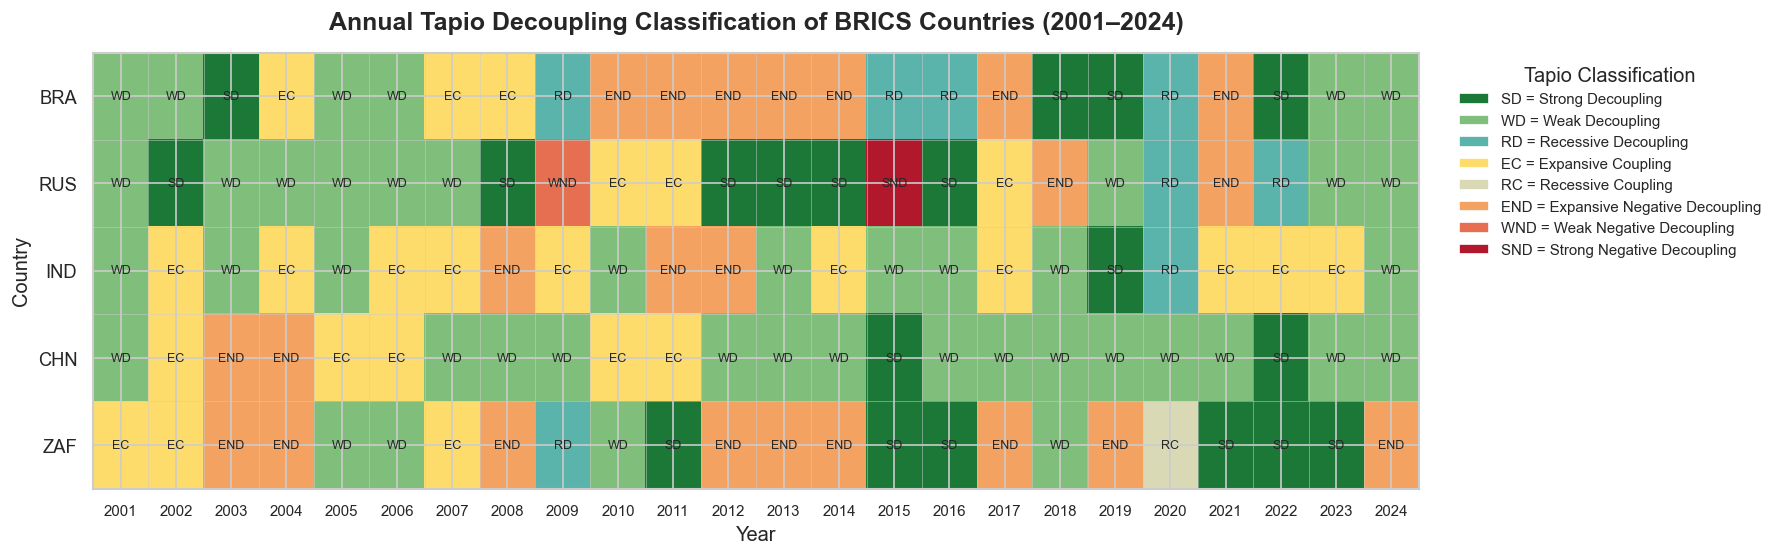

In [42]:
# Annual Tapio Heatmap - Full 8 Categories
# Logical colour scheme

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# 1. Tapio category coding

tapio_categories = {
    "Strong Decoupling": 1,
    "Weak Decoupling": 2,
    "Recessive Decoupling": 3,
    "Expansive Coupling": 4,
    "Recessive Coupling": 5,
    "Expansive Negative Decoupling": 6,
    "Weak Negative Decoupling": 7,
    "Strong Negative Decoupling": 8
}

category_abbr = {
    1: "SD",
    2: "WD",
    3: "RD",
    4: "EC",
    5: "RC",
    6: "END",
    7: "WND",
    8: "SND"
}

rq3["tapio_code"] = rq3["tapio_category"].map(tapio_categories)

# 2. heatmap matrix

heatmap_data = (
    rq3
    .pivot(
        index="country_code",
        columns="Year",
        values="tapio_code"
    )
    .reindex(["BRA", "RUS", "IND", "CHN", "ZAF"])
)

# Remove 2000 because no previous year exists
heatmap_data = heatmap_data.loc[:, 2001:2024]

# 3. Logical colour scheme

colors = [
    "#1B7837",  # 1 SD - dark green
    "#7FBF7B",  # 2 WD - light green
    "#5AB4AC",  # 3 RD - teal
    "#FDDC6C",  # 4 EC - yellow
    "#D9D9B6",  # 5 RC - muted yellow-grey
    "#F4A261",  # 6 END - orange
    "#E76F51",  # 7 WND - coral red
    "#B2182B"   # 8 SND - dark red
]

cmap = ListedColormap(colors)

norm = BoundaryNorm(
    boundaries=np.arange(0.5, 9.5, 1),
    ncolors=8
)


fig, ax = plt.subplots(figsize=(15, 4.8))

masked_data = np.ma.masked_invalid(
    heatmap_data.values
)

ax.imshow(
    masked_data,
    aspect="auto",
    cmap=cmap,
    norm=norm
)


ax.set_xticks(
    np.arange(len(heatmap_data.columns))
)

ax.set_xticklabels(
    heatmap_data.columns,
    rotation=0,
    fontsize=9
)

ax.set_yticks(
    np.arange(len(heatmap_data.index))
)

ax.set_yticklabels(
    heatmap_data.index,
    fontsize=11
)

ax.set_xlabel("Year")
ax.set_ylabel("Country")

ax.set_title(
    "Annual Tapio Decoupling Classification of BRICS Countries (2001–2024)",
    fontsize=15,
    fontweight="bold",
    pad=14
)


for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):

        value = heatmap_data.iloc[i, j]

        if pd.notna(value):

            ax.text(
                j,
                i,
                category_abbr[int(value)],
                ha="center",
                va="center",
                fontsize=7.5
            )


ax.set_xticks(
    np.arange(-0.5, heatmap_data.shape[1], 1),
    minor=True
)

ax.set_yticks(
    np.arange(-0.5, heatmap_data.shape[0], 1),
    minor=True
)

ax.grid(
    which="minor",
    linewidth=0.3
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)

legend_handles = [
    Patch(facecolor=colors[0], label="SD = Strong Decoupling"),
    Patch(facecolor=colors[1], label="WD = Weak Decoupling"),
    Patch(facecolor=colors[2], label="RD = Recessive Decoupling"),
    Patch(facecolor=colors[3], label="EC = Expansive Coupling"),
    Patch(facecolor=colors[4], label="RC = Recessive Coupling"),
    Patch(facecolor=colors[5], label="END = Expansive Negative Decoupling"),
    Patch(facecolor=colors[6], label="WND = Weak Negative Decoupling"),
    Patch(facecolor=colors[7], label="SND = Strong Negative Decoupling")
]

ax.legend(
    handles=legend_handles,
    title="Tapio Classification",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=9
)

plt.tight_layout()
plt.show()

In [43]:
# Five-year period decoupling analysis
periods = [
    (2000, 2004),
    (2005, 2009),
    (2010, 2014),
    (2015, 2019),
    (2020, 2024)
]

period_results = []

for country in rq3["country"].unique():

    country_data = (
        rq3[rq3["country"] == country]
        .set_index("Year")
        .sort_index()
    )
    for start_year, end_year in periods:

        start = country_data.loc[start_year]
        end = country_data.loc[end_year]

        # Proportional change in GDP
        gdp_change = (
            end["gdp_constant_2015_usd"]
            / start["gdp_constant_2015_usd"]
            - 1
        )

        # Proportional change in CO2 emissions
        co2_change = (
            end["co2_total_mt"]
            / start["co2_total_mt"]
            - 1
        )

        # Tapio elasticity
        elasticity = (
            co2_change / gdp_change
            if gdp_change != 0
            else np.nan
        )

        temp_row = pd.Series({
            "gdp_growth": gdp_change,
            "co2_growth": co2_change,
            "tapio_elasticity": elasticity
        })

        category = classify_tapio(temp_row)

        period_results.append({
            "Country": start["country_code"],
            "Period": f"{start_year}-{end_year}",
            "GDP change (%)": gdp_change * 100,
            "CO2 change (%)": co2_change * 100,
            "Tapio elasticity": elasticity,
            "Tapio category": category
        })

period_df = pd.DataFrame(period_results)
display(period_df)

,Country,Period,GDP change (%),CO2 change (%),Tapio elasticity,Tapio category
0,BRA,2000-2004,11.765,4.551,0.387,Weak Decoupling
1,BRA,2005-2009,15.744,4.424,0.281,Weak Decoupling
2,BRA,2010-2014,9.706,24.213,2.495,Expansive Negative Decoupling
3,BRA,2015-2019,0.969,-9.530,-9.831,Strong Decoupling
4,BRA,2020-2024,15.231,9.722,0.638,Weak Decoupling
5,CHN,2000-2004,43.498,50.670,1.165,Expansive Coupling
6,CHN,2005-2009,54.319,33.412,0.615,Weak Decoupling
7,CHN,2010-2014,36.739,19.494,0.531,Weak Decoupling
8,CHN,2015-2019,29.240,9.890,0.338,Weak Decoupling
9,CHN,2020-2024,23.911,9.701,0.406,Weak Decoupling


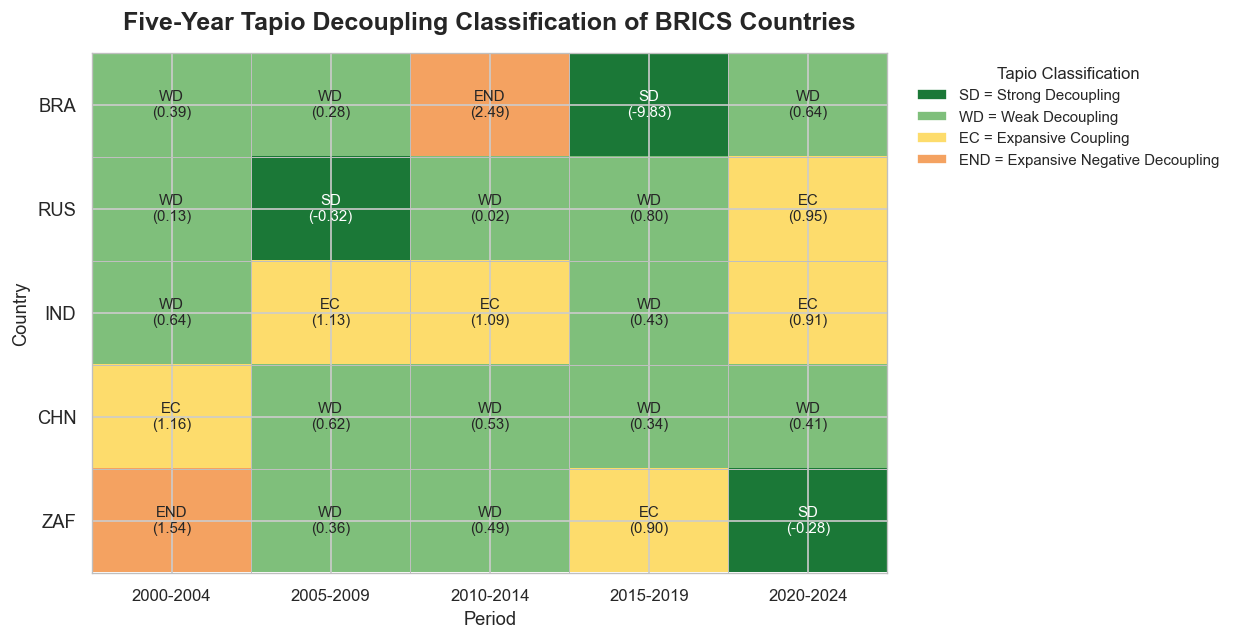

In [44]:
# Five-Year Period Tapio Heatmap-new

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# 1. Tapio classification

tapio_categories = {
    "Strong Decoupling": 1,
    "Weak Decoupling": 2,
    "Recessive Decoupling": 3,
    "Expansive Coupling": 4,
    "Recessive Coupling": 5,
    "Expansive Negative Decoupling": 6,
    "Weak Negative Decoupling": 7,
    "Strong Negative Decoupling": 8
}

category_abbr = {
    1: "SD",
    2: "WD",
    3: "RD",
    4: "EC",
    5: "RC",
    6: "END",
    7: "WND",
    8: "SND"
}
period_df["tapio_code"] = (
    period_df["Tapio category"]
    .map(tapio_categories)
)

# 2. Build matrices

period_order = [
    "2000-2004",
    "2005-2009",
    "2010-2014",
    "2015-2019",
    "2020-2024"
]

country_order = [
    "BRA",
    "RUS",
    "IND",
    "CHN",
    "ZAF"
]

period_heatmap = (
    period_df
    .pivot(
        index="Country",
        columns="Period",
        values="tapio_code"
    )
    .reindex(
        index=country_order,
        columns=period_order
    )
)

period_elasticity = (
    period_df
    .pivot(
        index="Country",
        columns="Period",
        values="Tapio elasticity"
    )
    .reindex(
        index=country_order,
        columns=period_order
    )
)

# 3. Logical colour scheme

colors = [
    "#1B7837",  # 1 SD  - dark green
    "#7FBF7B",  # 2 WD  - light green
    "#5AB4AC",  # 3 RD  - teal
    "#FDDC6C",  # 4 EC  - yellow
    "#D9D9B6",  # 5 RC  - muted yellow-grey
    "#F4A261",  # 6 END - orange
    "#E76F51",  # 7 WND - coral red
    "#B2182B"   # 8 SND - dark red
]

cmap = ListedColormap(colors)

norm = BoundaryNorm(
    boundaries=np.arange(0.5, 9.5, 1),
    ncolors=8
)


fig, ax = plt.subplots(figsize=(10.5, 5.5))

masked_data = np.ma.masked_invalid(
    period_heatmap.values
)

ax.imshow(
    masked_data,
    aspect="auto",
    cmap=cmap,
    norm=norm
)

ax.set_xticks(
    np.arange(len(period_heatmap.columns))
)

ax.set_xticklabels(
    period_heatmap.columns,
    fontsize=10
)

ax.set_yticks(
    np.arange(len(period_heatmap.index))
)

ax.set_yticklabels(
    period_heatmap.index,
    fontsize=11
)

ax.set_xlabel(
    "Period",
    fontsize=11
)

ax.set_ylabel(
    "Country",
    fontsize=11
)

ax.set_title(
    "Five-Year Tapio Decoupling Classification of BRICS Countries",
    fontsize=15,
    fontweight="bold",
    pad=14
)

# Add category abbreviation + elasticity

for i in range(period_heatmap.shape[0]):
    for j in range(period_heatmap.shape[1]):

        value = period_heatmap.iloc[i, j]
        elasticity = period_elasticity.iloc[i, j]

        if pd.notna(value):

            label = (
                f"{category_abbr[int(value)]}\n"
                f"({elasticity:.2f})"
            )

            # White text on dark green SD cells
            text_color = (
                "white"
                if int(value) == 1
                else "#262626"
            )

            ax.text(
                j,
                i,
                label,
                ha="center",
                va="center",
                fontsize=9,
                color=text_color
            )

ax.set_xticks(
    np.arange(-0.5, period_heatmap.shape[1], 1),
    minor=True
)

ax.set_yticks(
    np.arange(-0.5, period_heatmap.shape[0], 1),
    minor=True
)

ax.grid(
    which="minor",
    color="#BFBFBF",
    linewidth=0.6
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)

# Optional: soften outer border
for spine in ax.spines.values():
    spine.set_color("#BFBFBF")
    spine.set_linewidth(0.8)


legend_handles = [
    Patch(
        facecolor=colors[0],
        label="SD = Strong Decoupling"
    ),
    Patch(
        facecolor=colors[1],
        label="WD = Weak Decoupling"
    ),
    Patch(
        facecolor=colors[3],
        label="EC = Expansive Coupling"
    ),
    Patch(
        facecolor=colors[5],
        label="END = Expansive Negative Decoupling"
    )
]

ax.legend(
    handles=legend_handles,
    title="Tapio Classification",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=9,
    title_fontsize=10
)

plt.tight_layout()

plt.show()

In [45]:
# Dominant decoupling pattern by country

dominant_pattern = (
    rq3
    .dropna(subset=["tapio_category"])
    .groupby(["country_code", "tapio_category"])
    .size()
    .reset_index(name="Years")
)

dominant_pattern["Rank"] = (
    dominant_pattern
    .groupby("country_code")["Years"]
    .rank(
        method="first",
        ascending=False
    )
)

dominant_pattern = (
    dominant_pattern[
        dominant_pattern["Rank"] == 1
    ]
    .drop(columns="Rank")
    .rename(
        columns={
            "country_code": "Country",
            "tapio_category": "Dominant Tapio pattern"
        }
    )
)

display(dominant_pattern)

,Country,Dominant Tapio pattern,Years
1,BRA,Expansive Negative Decoupling,7
8,CHN,Weak Decoupling,15
9,IND,Expansive Coupling,10
19,RUS,Weak Decoupling,9
22,ZAF,Expansive Negative Decoupling,9


# Diagnostic Tests

In [47]:
# Estimate FE

from linearmodels.panel import PanelOLS, RandomEffects

fe = PanelOLS.from_formula(
    """
    ln_co2_total
    ~ 1
    + urban_population_pct
    + ln_gdp
    + EntityEffects
    + TimeEffects
    """,
    data=panel_rq2
).fit(cov_type="robust")

In [48]:
# Estimate RE

re = RandomEffects.from_formula(
    """
    ln_co2_total
    ~ 1
    + urban_population_pct
    + ln_gdp
    """,
    data=panel_rq2
).fit(cov_type="robust")

In [49]:
# Hausman test
import numpy as np
from scipy.stats import chi2

def hausman(fe, re):

    b = fe.params
    B = re.params

    common = b.index.intersection(B.index)

    b = b.loc[common]
    B = B.loc[common]

    vb = fe.cov.loc[common, common]
    vB = re.cov.loc[common, common]

    diff = b - B

    stat = float(
        diff.T
        @ np.linalg.inv(vb - vB)
        @ diff
    )

    df = len(diff)

    pval = 1 - chi2.cdf(stat, df)

    return stat, df, pval

stat, df, p = hausman(fe, re)

print(f"Hausman statistic = {stat:.3f}")
print(f"Degrees of freedom = {df}")
print(f"P-value = {p:.4f}")

Hausman statistic = 8.725
Degrees of freedom = 3
P-value = 0.0332


In [50]:
# VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

vif_df = panel_rq2.reset_index()

X = vif_df[
    [
        "urban_population_pct",
        "ln_gdp"
    ]
].copy()

# add constant
X = add_constant(X)

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

# remove constant
vif = vif[vif["Variable"] != "const"].copy()
vif["Tolerance"] = 1 / vif["VIF"]

display(vif.round(3))

,Variable,VIF,Tolerance
1,urban_population_pct,1.014,0.986
2,ln_gdp,1.014,0.986


In [51]:
corr = panel_rq2.reset_index()[[
    "urban_population_pct",
    "ln_gdp"
]].corr()

display(corr.round(3))

Variable,urban_population_pct,ln_gdp
Variable,,
urban_population_pct,1.000,-0.117
ln_gdp,-0.117,1.000


<Axes: xlabel='urban_population_pct', ylabel='ln_gdp'>

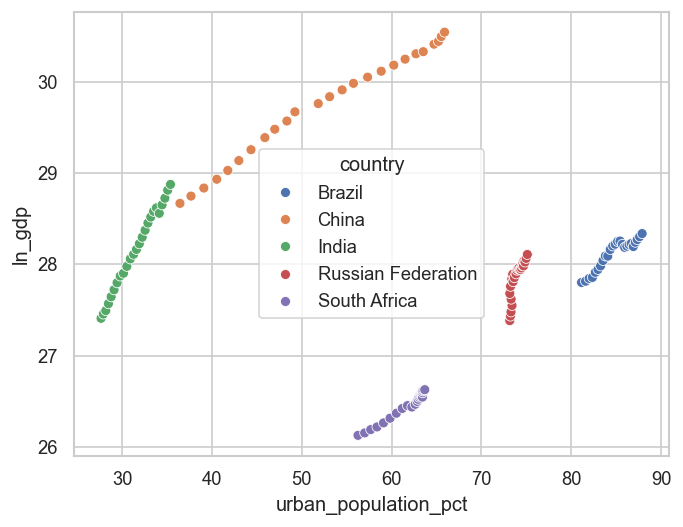

In [52]:
sns.scatterplot(
    data=panel_rq2.reset_index(),
    x="urban_population_pct",
    y="ln_gdp",
    hue="country"
)

In [53]:
# Pesaran Cross-sectional Dependence Test
import numpy as np
import pandas as pd
from scipy.stats import norm

def pesaran_cd(residuals):

    """
    residuals:
        pandas Series
        MultiIndex = (country, year)
    """

    # Country × Year
    e = residuals.unstack(level=0)

    T = e.shape[0]
    N = e.shape[1]

    rho = []

    for i in range(N):

        for j in range(i + 1, N):

            corr = np.corrcoef(
                e.iloc[:, i],
                e.iloc[:, j]
            )[0, 1]

            rho.append(corr)

    rho = np.array(rho)

    CD = np.sqrt(
        2 * T / (N * (N - 1))
    ) * rho.sum()

    p = 2 * (1 - norm.cdf(abs(CD)))

    return CD, p

cd_stat, p_value = pesaran_cd(res2.resids)

print(f"Pesaran CD statistic = {cd_stat:.3f}")
print(f"P-value = {p_value:.4f}")

Pesaran CD statistic = -3.346
P-value = 0.0008


In [54]:
models = {
    "M1": res1,
    "M2": res2,
    "M3": res3,
    "M4": res4
}

cd_results = []

for name, model in models.items():

    cd_stat, p_value = pesaran_cd(model.resids)

    cd_results.append({
        "Model": name,
        "CD statistic": cd_stat,
        "p-value": p_value,
        "Cross-sectional dependence":
            "Yes" if p_value < 0.05 else "No"
    })

cd_table = pd.DataFrame(cd_results)

display(cd_table.round(3))

,Model,CD statistic,p-value,Cross-sectional dependence
0,M1,-2.534,0.011,Yes
1,M2,-3.346,0.001,Yes
2,M3,-3.630,0.000,Yes
3,M4,-2.965,0.003,Yes


In [55]:
# Model Diagnostics Summary

diagnostics_summary = pd.DataFrame({
    "Diagnostic Test": [
        "Hausman test",
        "Variance Inflation Factor (VIF)",
        "Pesaran CD test",
        "Robust vs Driscoll–Kraay SE"
    ],
    
    "Purpose": [
        "Fixed vs random effects",
        "Multicollinearity",
        "Cross-sectional dependence",
        "Robustness of statistical inference"
    ],
    
    "Result": [
        "χ² = 8.725; p = 0.033",
        "VIF = 1.014 (both regressors)",
        "M1: p = 0.011; M2: p = 0.001; "
        "M3: p < 0.001; M4: p = 0.003",
        "Main statistical conclusions unchanged"
    ],
    
    "Conclusion": [
        "Fixed effects preferred",
        "No multicollinearity concern",
        "Cross-sectional dependence in all models",
        "Driscoll–Kraay SE adopted for final inference"
    ]
})

display(diagnostics_summary)

,Diagnostic Test,Purpose,Result,Conclusion
0,Hausman test,Fixed vs random effects,χ² = 8.725; p = 0.033,Fixed effects preferred
1,Variance Inflation Factor (VIF),Multicollinearity,VIF = 1.014 (both regressors),No multicollinearity concern
2,Pesaran CD test,Cross-sectional dependence,M1: p = 0.011; M2: p = 0.001; M3: p < 0.001; M...,Cross-sectional dependence in all models
3,Robust vs Driscoll–Kraay SE,Robustness of statistical inference,Main statistical conclusions unchanged,Driscoll–Kraay SE adopted for final inference


In [56]:
styled_diagnostics = (
    diagnostics_summary.style
    .hide(axis="index")
    .set_caption("Model Diagnostics Summary")
    .set_properties(**{
        "text-align": "left",
        "white-space": "normal"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "left"),
                ("font-weight", "bold")
            ]
        }
    ])
)

display(styled_diagnostics)

Diagnostic Test,Purpose,Result,Conclusion
Hausman test,Fixed vs random effects,χ² = 8.725; p = 0.033,Fixed effects preferred
Variance Inflation Factor (VIF),Multicollinearity,VIF = 1.014 (both regressors),No multicollinearity concern
Pesaran CD test,Cross-sectional dependence,M1: p = 0.011; M2: p = 0.001; M3: p < 0.001; M4: p = 0.003,Cross-sectional dependence in all models
Robust vs Driscoll–Kraay SE,Robustness of statistical inference,Main statistical conclusions unchanged,Driscoll–Kraay SE adopted for final inference


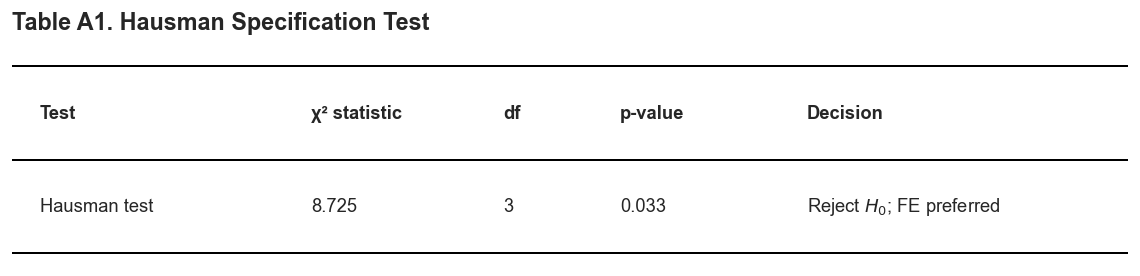

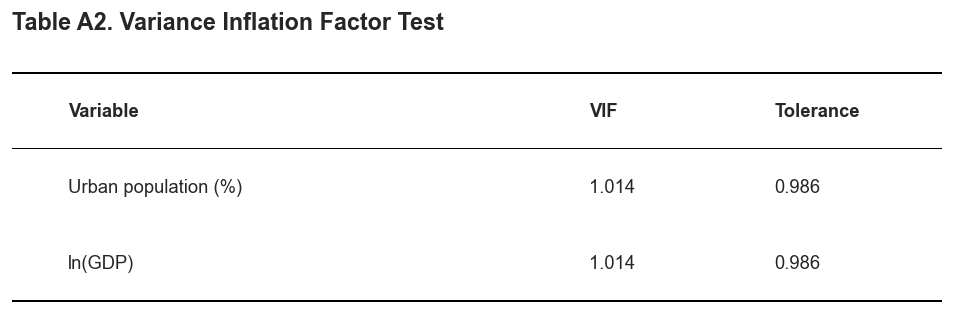

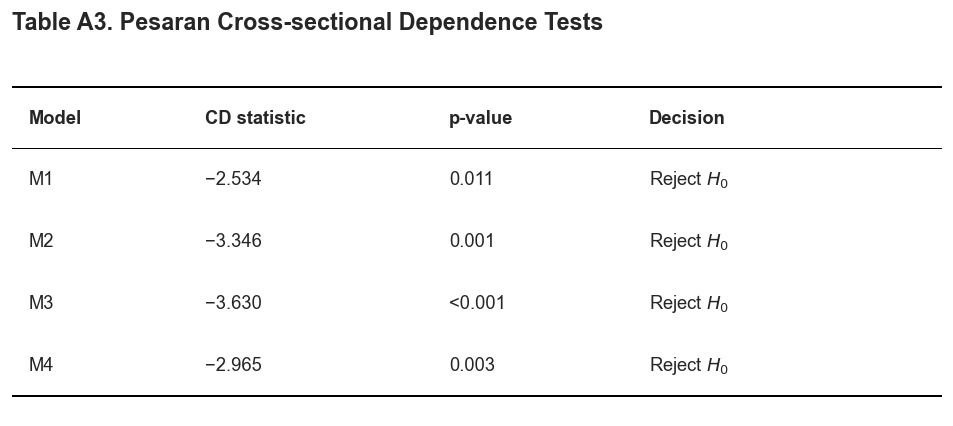

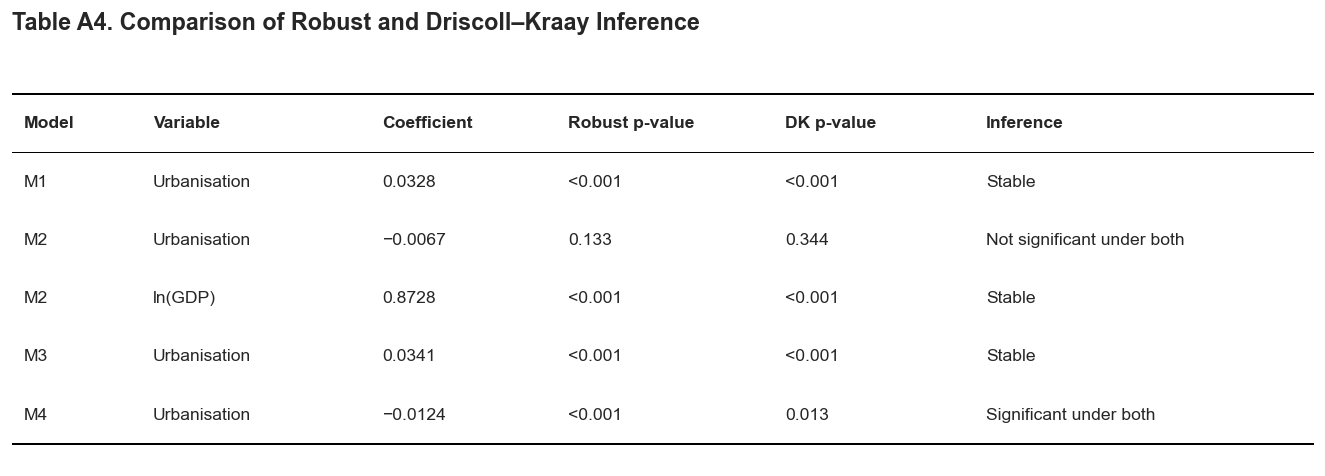

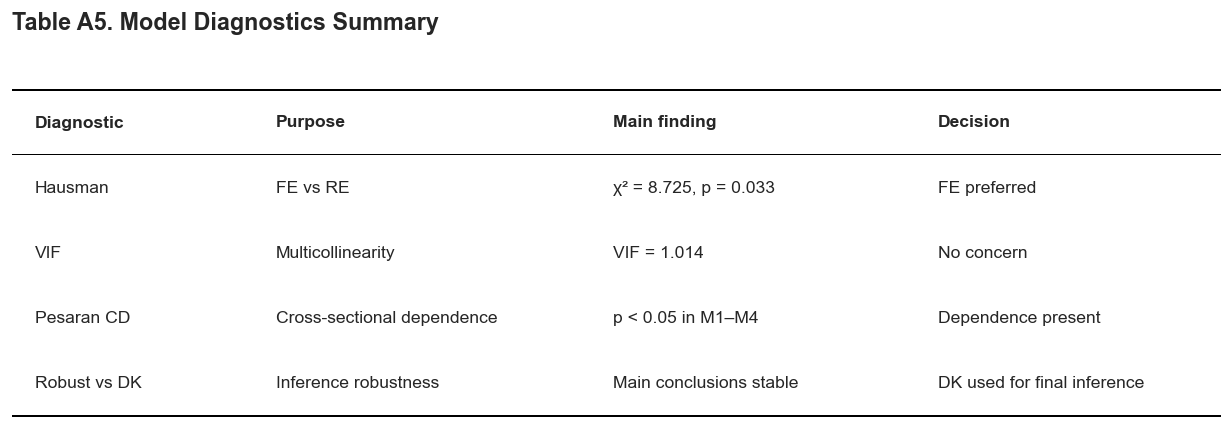

In [57]:
import matplotlib.pyplot as plt
import pandas as pd

def three_line_table(
    df,
    title,
    filename,
    col_widths=None,
    figsize=(12, 3),
    fontsize=11
):
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")

    # Table title
    ax.text(
        0,
        1.08,
        title,
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        ha="left",
        va="bottom"
    )

    # Create table
    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="left",
        colLoc="left",
        loc="upper left",
        bbox=[0, 0.05, 1, 0.88],
        colWidths=col_widths
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)

    nrows = len(df) + 1
    ncols = len(df.columns)
    
     # Remove all borders
    # --------------------------------------------------------
    for (row, col), cell in table.get_celld().items():
        cell.set_facecolor("white")
        cell.set_edgecolor("black")
        cell.set_linewidth(0)

        if row == 0:
            cell.set_text_props(weight="bold")

    # Top rule + middle rule under header
    for col in range(ncols):
        cell = table[(0, col)]
        cell.visible_edges = "TB"
        cell.set_linewidth(1.2)

    # Bottom rule
    for col in range(ncols):
        cell = table[(nrows - 1, col)]
        cell.visible_edges = "B"
        cell.set_linewidth(1.2)

    # Slightly increase row height
    table.scale(1, 1.5)

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# TABLE A1
# Hausman Specification Test

table_a1 = pd.DataFrame({
    "Test": [
        "Hausman test"
    ],
    "χ² statistic": [
        "8.725"
    ],
    "df": [
        "3"
    ],
    "p-value": [
        "0.033"
    ],
    "Decision": [
        "Reject $H_0$; FE preferred"
    ]
})

three_line_table(
    table_a1,
    title="Table A1. Hausman Specification Test",
    filename="Table_A1_Hausman.png",
    col_widths=[0.25, 0.18, 0.10, 0.15, 0.32],
    figsize=(12, 2.3)
)

# TABLE A2
# Variance Inflation Factor Test

table_a2 = pd.DataFrame({
    "Variable": [
        "Urban population (%)",
        "ln(GDP)"
    ],
    "VIF": [
        "1.014",
        "1.014"
    ],
    "Tolerance": [
        "0.986",
        "0.986"
    ]
})

three_line_table(
    table_a2,
    title="Table A2. Variance Inflation Factor Test",
    filename="Table_A2_VIF.png",
    col_widths=[0.60, 0.20, 0.20],
    figsize=(10, 2.8)
)

# TABLE A3
# Pesaran Cross-sectional Dependence Tests

table_a3 = pd.DataFrame({
    "Model": [
        "M1",
        "M2",
        "M3",
        "M4"
    ],
    "CD statistic": [
        "−2.534",
        "−3.346",
        "−3.630",
        "−2.965"
    ],
    "p-value": [
        "0.011",
        "0.001",
        "<0.001",
        "0.003"
    ],
    "Decision": [
        r"Reject $H_0$",
        r"Reject $H_0$",
        r"Reject $H_0$",
        r"Reject $H_0$"
]
})

three_line_table(
    table_a3,
    title="Table A3. Pesaran Cross-sectional Dependence Tests",
    filename="Table_A3_Pesaran_CD.png",
    col_widths=[0.18, 0.27, 0.20, 0.35],
    figsize=(10, 3.8)
)

# TABLE A4
# Robust vs Driscoll–Kraay

table_a4 = pd.DataFrame({
    "Model": [
        "M1",
        "M2",
        "M2",
        "M3",
        "M4"
    ],
    "Variable": [
        "Urbanisation",
        "Urbanisation",
        "ln(GDP)",
        "Urbanisation",
        "Urbanisation"
    ],
    "Coefficient": [
        "0.0328",
        "−0.0067",
        "0.8728",
        "0.0341",
        "−0.0124"
    ],
    "Robust p-value": [
        "<0.001",
        "0.133",
        "<0.001",
        "<0.001",
        "<0.001"
    ],
    "DK p-value": [
        "<0.001",
        "0.344",
        "<0.001",
        "<0.001",
        "0.013"
    ],
    "Inference": [
        "Stable",
        "Not significant under both",
        "Stable",
        "Stable",
        "Significant under both"
    ]
})

three_line_table(
    table_a4,
    title="Table A4. Comparison of Robust and Driscoll–Kraay Inference",
    filename="Table_A4_Robust_vs_DK.png",
    col_widths=[0.09, 0.18, 0.14, 0.17, 0.14, 0.28],
    figsize=(14, 4.3),
    fontsize=10.5
)

# TABLE A5
# Model Diagnostics Summary

table_a5 = pd.DataFrame({
    "Diagnostic": [
        "Hausman",
        "VIF",
        "Pesaran CD",
        "Robust vs DK"
    ],
    "Purpose": [
        "FE vs RE",
        "Multicollinearity",
        "Cross-sectional dependence",
        "Inference robustness"
    ],
    "Main finding": [
        "χ² = 8.725, p = 0.033",
        "VIF = 1.014",
        "p < 0.05 in M1–M4",
        "Main conclusions stable"
    ],
    "Decision": [
        "FE preferred",
        "No concern",
        "Dependence present",
        "DK used for final inference"
    ]
})

three_line_table(
    table_a5,
    title="Table A5. Model Diagnostics Summary",
    filename="Table_A5_Diagnostics_Summary.png",
    col_widths=[0.19, 0.28, 0.27, 0.26],
    figsize=(13, 4.0),
    fontsize=10.5
)

# Tapio classification framework

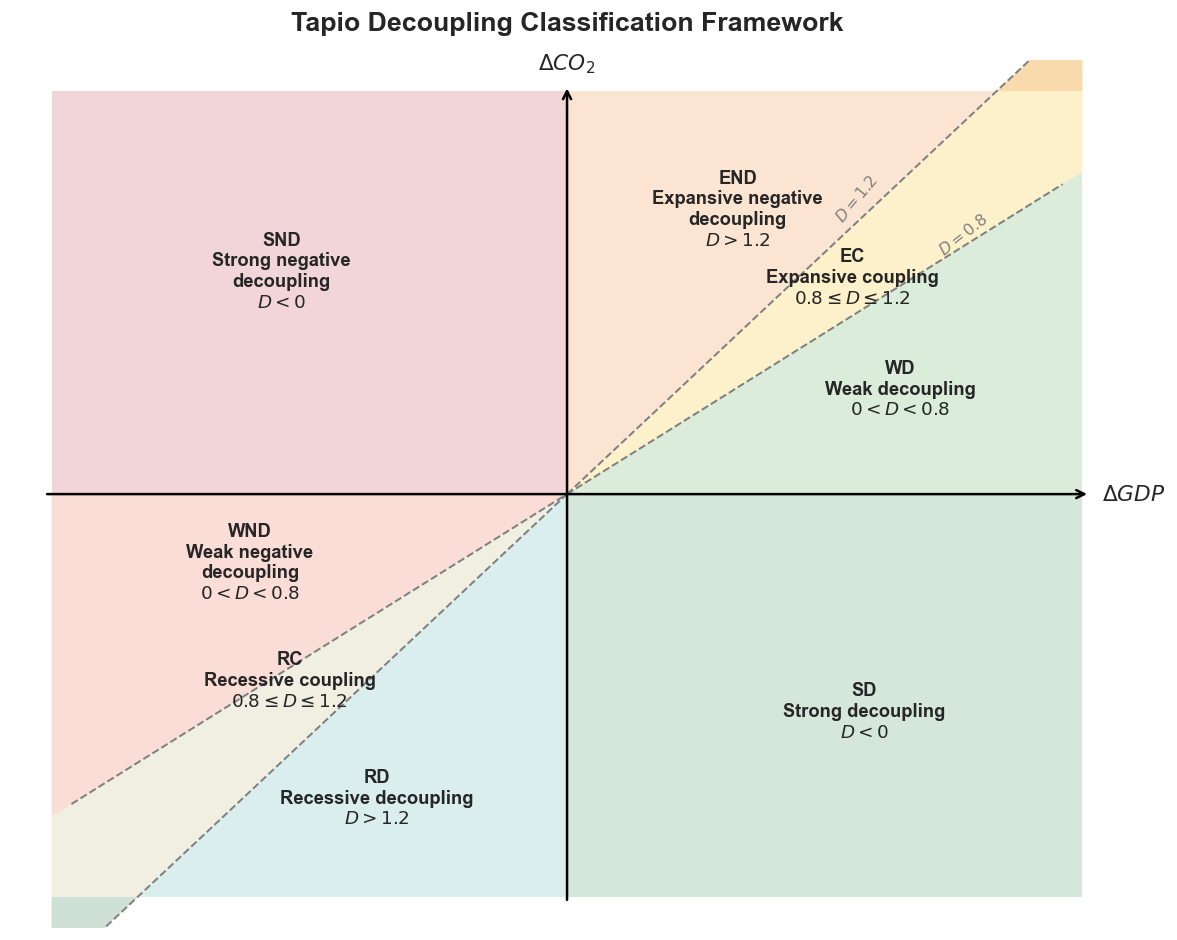

In [60]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np

# Tapio Decoupling Classification Framework

fig, ax = plt.subplots(figsize=(10, 8))

# Axis limits
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)

# Remove default spines/ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

# Colour palette

colors = {
    "SD":  "#1b7f3a",   # dark green
    "WD":  "#7fbf7b",   # light green
    "EC":  "#f9d86c",   # yellow
    "END": "#f4a15d",   # orange
    "RD":  "#62b6b3",   # teal
    "RC":  "#d8d5b4",   # beige-grey
    "WND": "#e76f51",   # orange-red
    "SND": "#b2182b"    # dark red
}


ax.annotate(
    "",
    xy=(1.32, 0),
    xytext=(-1.32, 0),
    arrowprops=dict(arrowstyle="->", lw=1.5, color="black")
)

ax.annotate(
    "",
    xy=(0, 1.32),
    xytext=(0, -1.32),
    arrowprops=dict(arrowstyle="->", lw=1.5, color="black")
)

ax.text(
    1.35, 0,

    r"$\Delta GDP$",
    ha="left",
    va="center",
    fontsize=13,
    fontweight="bold"
)

ax.text(
    0, 1.35,
    r"$\Delta CO_2$",
    ha="center",
    va="bottom",
    fontsize=13,
    fontweight="bold"
)

# Tapio threshold lines
# D = ΔCO2 / ΔGDP
# ΔCO2 = 0.8 × ΔGDP
# ΔCO2 = 1.2 × ΔGDP

x_pos = np.linspace(0, 1.25, 200)
x_neg = np.linspace(-1.25, 0, 200)

# Positive-growth quadrant
ax.plot(
    x_pos,
    0.8 * x_pos,
    linestyle="--",
    linewidth=1.2,

    color="gray"
)

ax.plot(
    x_pos,
    1.2 * x_pos,
    linestyle="--",
    linewidth=1.2,
    color="gray"
)

# Negative-growth quadrant
ax.plot(
    x_neg,
    0.8 * x_neg,
    linestyle="--",
    linewidth=1.2,
    color="gray"
)

ax.plot(
    x_neg,
    1.2 * x_neg,
    linestyle="--",
    linewidth=1.2,
    color="gray"
)

# Background classification regions

# Strong negative decoupling
snd = Polygon(
    [(-1.3, 0), (-1.3, 1.3), (0, 1.3), (0, 0)],
    closed=True,
    facecolor=colors["SND"],
    alpha=0.18,

    edgecolor="none"
)
ax.add_patch(snd)

# Strong decoupling
sd = Polygon(
    [(0, 0), (1.3, 0), (1.3, -1.3), (0, -1.3)],
    closed=True,
    facecolor=colors["SD"],
    alpha=0.18,
    edgecolor="none"
)
ax.add_patch(sd)

# Positive GDP, positive CO2
# WD
wd = Polygon(
    [(0, 0), (1.3, 0), (1.3, 0.8 * 1.3)],
    closed=True,
    facecolor=colors["WD"],
    alpha=0.28,
    edgecolor="none"
)
ax.add_patch(wd)



ec = Polygon(
    [
        (0, 0),
        (1.3, 0.8 * 1.3),
        (1.3, 1.2 * 1.3)
    ],
    closed=True,
    facecolor=colors["EC"],
    alpha=0.35,
    edgecolor="none"
)
ax.add_patch(ec)

# END
end = Polygon(
    [
        (0, 0),
        (1.3, 1.2 * 1.3),
        (1.3, 1.3),
        (0, 1.3)
    ],
    closed=True,
    facecolor=colors["END"],
    alpha=0.28,
    edgecolor="none"
)
ax.add_patch(end)

# Negative GDP, negative CO2
# WND
wnd = Polygon(
    [
        (-1.3, 0),
        (0, 0),
        (-1.3, 0.8 * -1.3)
    ],
    closed=True,
    facecolor=colors["WND"],
    alpha=0.23,

    edgecolor="none"
)
ax.add_patch(wnd)

# RC
rc = Polygon(
    [
        (0, 0),
        (-1.3, 0.8 * -1.3),
        (-1.3, 1.2 * -1.3)
    ],
    closed=True,
    facecolor=colors["RC"],
    alpha=0.38,
    edgecolor="none"
)
ax.add_patch(rc)

# RD
rd = Polygon(
    [
        (0, 0),
        (-1.3, 1.2 * -1.3),
        (-1.3, -1.3),
        (0, -1.3)
    ],
    closed=True,
    facecolor=colors["RD"],
    alpha=0.23,
    edgecolor="none"
)
ax.add_patch(rd)


label_style = dict(
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold"
)

# Upper-left
ax.text(

    -0.72, 0.72,
    "SND\nStrong negative\ndecoupling\n$D<0$",
    **label_style
)

# Upper-right
ax.text(
    0.43, 0.92,
    "END\nExpansive negative\ndecoupling\n$D>1.2$",
    **label_style
)

ax.text(
    0.72, 0.70,
    "EC\nExpansive coupling\n$0.8\\leq D\\leq1.2$",
    **label_style
)

ax.text(
    0.84, 0.34,
    "WD\nWeak decoupling\n$0<D<0.8$",
    **label_style
)

# Lower-right
ax.text(
    0.75, -0.70,
    "SD\nStrong decoupling\n$D<0$",
    **label_style
)

# Lower-left
ax.text(
    -0.80, -0.22,
    "WND\nWeak negative\ndecoupling\n$0<D<0.8$",
    **label_style
)

ax.text(
    -0.70, -0.60,
    "RC\nRecessive coupling\n$0.8\\leq D\\leq1.2$",
    **label_style
)

ax.text(
    -0.48, -0.98,
    "RD\nRecessive decoupling\n$D>1.2$",
    **label_style
)

# Threshold annotations

ax.text(
    0.93, 0.77,
    r"$D=0.8$",
    fontsize=9.5,
    color="gray",
    rotation=38
)

ax.text(
    0.67, 0.88,
    r"$D=1.2$",
    fontsize=9.5,
    color="gray",
    rotation=50
)

ax.set_title(
    "Tapio Decoupling Classification Framework",
    fontsize=16,
    fontweight="bold",
    pad=18
)

plt.tight_layout()


# Stationarity tests and country-specific trend specifications

In [70]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller

# Prepare data

stationarity_df = panel_df.copy()

stationarity_df = (
    stationarity_df
    .sort_values(["country", "Year"])
    .reset_index(drop=True)
)

stationarity_df["ln_co2_total"] = np.log(
    stationarity_df["co2_total_mt"]
)

stationarity_df["ln_co2_per_capita"] = np.log(
    stationarity_df["co2_per_capita"]
)

stationarity_df["ln_carbon_intensity"] = np.log(
    stationarity_df["carbon_intensity"]
)

stationarity_df["ln_gdp"] = np.log(
    stationarity_df["gdp_constant_2015_usd"]
)

test_vars = {
    "Urbanisation": "urban_population_pct",
    "Total CO2": "ln_co2_total",
    "CO2 per capita": "ln_co2_per_capita",
    "Carbon intensity": "ln_carbon_intensity",
    "GDP": "ln_gdp"
}


# ADF function

def run_adf(series, regression="ct"):
    
    series = series.dropna()

    result = adfuller(
        series,
        maxlag=1,           # important for T = 25
        regression=regression,
        autolag=None
    )

    return {
        "ADF statistic": result[0],
        "p-value": result[1],
        "lags": result[2],
        "nobs": result[3]
    }


# LEVEL TESTS
# constant + trend

level_results = []

for country in stationarity_df["country"].unique():

    country_data = (
        stationarity_df[
            stationarity_df["country"] == country
        ]
        .sort_values("Year")
    )

    for label, var in test_vars.items():

        result = run_adf(
            country_data[var],
            regression="ct"
        )

        level_results.append({
            "Country": country,
            "Variable": label,
            "ADF statistic": result["ADF statistic"],
            "p-value": result["p-value"],
            "Stationary at 5%": result["p-value"] < 0.05
        })

level_adf = pd.DataFrame(level_results)

print("ADF TESTS — LEVELS")
display(level_adf.round(4))

# FIRST-DIFFERENCE TESTS
# constant only

diff_results = []

for country in stationarity_df["country"].unique():

    country_data = (
        stationarity_df[
            stationarity_df["country"] == country
        ]
        .sort_values("Year")
    )

    for label, var in test_vars.items():

        diff_series = country_data[var].diff()

        result = run_adf(
            diff_series,
            regression="c"
        )

        diff_results.append({
            "Country": country,
            "Variable": label,
            "ADF statistic": result["ADF statistic"],
            "p-value": result["p-value"],
            "Stationary at 5%": result["p-value"] < 0.05
        })

diff_adf = pd.DataFrame(diff_results)

print("\nADF TESTS — FIRST DIFFERENCES")
display(diff_adf.round(4))

ADF TESTS — LEVELS


,Country,Variable,ADF statistic,p-value,Stationary at 5%
0,Brazil,Urbanisation,-1.690,0.755,False
1,Brazil,Total CO2,-1.108,0.928,False
2,Brazil,CO2 per capita,-1.257,0.898,False
3,Brazil,Carbon intensity,-1.722,0.741,False
4,Brazil,GDP,-1.641,0.776,False
5,China,Urbanisation,1.478,1.000,False
6,China,Total CO2,-2.536,0.310,False
7,China,CO2 per capita,-2.670,0.249,False
8,China,Carbon intensity,-3.898,0.012,True
9,China,GDP,0.094,0.995,False



ADF TESTS — FIRST DIFFERENCES


,Country,Variable,ADF statistic,p-value,Stationary at 5%
0,Brazil,Urbanisation,-2.994,0.035,True
1,Brazil,Total CO2,-2.916,0.043,True
2,Brazil,CO2 per capita,-2.970,0.038,True
3,Brazil,Carbon intensity,-2.929,0.042,True
4,Brazil,GDP,-2.345,0.158,False
5,China,Urbanisation,-0.816,0.814,False
6,China,Total CO2,-1.423,0.571,False
7,China,CO2 per capita,-1.496,0.535,False
8,China,Carbon intensity,-2.496,0.116,False
9,China,GDP,-0.760,0.831,False


In [71]:
level_matrix = level_adf.pivot(
    index="Variable",
    columns="Country",
    values="p-value"
)

diff_matrix = diff_adf.pivot(
    index="Variable",
    columns="Country",
    values="p-value"
)

print("LEVEL p-values")
display(level_matrix.round(3))

print("\nFIRST-DIFFERENCE p-values")
display(diff_matrix.round(3))

LEVEL p-values


Country,Brazil,China,India,Russian Federation,South Africa
Variable,,,,,
CO2 per capita,0.898,0.249,0.742,0.679,0.423
Carbon intensity,0.741,0.012,0.797,0.646,0.017
GDP,0.776,0.995,0.445,0.431,0.878
Total CO2,0.928,0.310,0.824,0.601,0.445
Urbanisation,0.755,1.000,0.105,0.221,0.003



FIRST-DIFFERENCE p-values


Country,Brazil,China,India,Russian Federation,South Africa
Variable,,,,,
CO2 per capita,0.038,0.535,0.015,0.001,0.139
Carbon intensity,0.042,0.116,0.051,0.160,0.003
GDP,0.158,0.831,0.007,0.106,0.102
Total CO2,0.044,0.571,0.021,0.000,0.120
Urbanisation,0.035,0.814,0.137,0.008,0.673


In [72]:
# country-specific linear trends
import numpy as np
import pandas as pd

from linearmodels.panel import PanelOLS


trend_df = panel_df.copy()

trend_df = (
    trend_df
    .sort_values(["country", "Year"])
    .reset_index(drop=True)
)

# Same log transformations as the original M1–M4 models
trend_df["ln_co2_total"] = np.log(trend_df["co2_total_mt"])
trend_df["ln_co2_per_capita"] = np.log(trend_df["co2_per_capita"])
trend_df["ln_carbon_intensity"] = np.log(trend_df["carbon_intensity"])
trend_df["ln_gdp"] = np.log(trend_df["gdp_constant_2015_usd"])

# Centre time at 2000
trend_df["trend"] = trend_df["Year"] - 2000


# Create country-specific linear trends

countries = trend_df["country"].unique().tolist()

print("Countries:")
print(countries)

# Use first country as reference to avoid perfect collinearity
reference_country = countries[0]

trend_variables = []

for country in countries[1:]:
    safe_name = (
        country.lower()
        .replace(" ", "_")
        .replace("-", "_")
    )
    
    var_name = f"trend_{safe_name}"
    
    trend_df[var_name] = (
        (trend_df["country"] == country).astype(int)
        * trend_df["trend"]
    )
    
    trend_variables.append(var_name)

print("\nReference country:", reference_country)
print("Country-specific trend variables:")
print(trend_variables)

# Set panel index

trend_panel = trend_df.set_index(["country", "Year"])


# Function for FE + country-specific trends

def run_trend_model(dependent, explanatory):
    
    exog_vars = explanatory + trend_variables
    
    model = PanelOLS(
        dependent=trend_panel[dependent],
        exog=trend_panel[exog_vars],
        entity_effects=True,
        time_effects=True,
        drop_absorbed=True
    )
    
    result = model.fit(
        cov_type="driscoll-kraay"
    )
    
    return result

# M1–M4 + country-specific linear trends

# M1: Total CO2 ~ Urbanisation
M1_trend = run_trend_model(
    "ln_co2_total",
    ["urban_population_pct"]
)

# M2: Total CO2 ~ Urbanisation + GDP
M2_trend = run_trend_model(
    "ln_co2_total",
    ["urban_population_pct", "ln_gdp"]
)

# M3: CO2 per capita ~ Urbanisation
M3_trend = run_trend_model(
    "ln_co2_per_capita",
    ["urban_population_pct"]
)

# M4: Carbon intensity ~ Urbanisation
M4_trend = run_trend_model(
    "ln_carbon_intensity",
    ["urban_population_pct"]
)

print("\n" + "="*80)
print("M1 — TOTAL CO2 + COUNTRY-SPECIFIC TRENDS")
print("="*80)
print(M1_trend.summary)

print("\n" + "="*80)
print("M2 — TOTAL CO2 + GDP + COUNTRY-SPECIFIC TRENDS")
print("="*80)
print(M2_trend.summary)

print("\n" + "="*80)
print("M3 — CO2 PER CAPITA + COUNTRY-SPECIFIC TRENDS")
print("="*80)
print(M3_trend.summary)

print("\n" + "="*80)
print("M4 — CARBON INTENSITY + COUNTRY-SPECIFIC TRENDS")
print("="*80)
print(M4_trend.summary)

Countries:
['Brazil', 'China', 'India', 'Russian Federation', 'South Africa']

Reference country: Brazil
Country-specific trend variables:
['trend_china', 'trend_india', 'trend_russian_federation', 'trend_south_africa']

M1 — TOTAL CO2 + COUNTRY-SPECIFIC TRENDS
                          PanelOLS Estimation Summary                           
Dep. Variable:           ln_co2_total   R-squared:                        0.8742
Estimator:                   PanelOLS   R-squared (Between):              0.4329
No. Observations:                 125   R-squared (Within):               0.8459
Date:                Wed, Aug 26 2026   R-squared (Overall):              0.4333
Time:                        01:05:11   Log-likelihood                    182.89
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      126.52
Entities:                           5   P-value                           0.0000
Avg Obs: 

In [73]:
# Compact comparison table

models = {
    "M1: Total CO2": M1_trend,
    "M2: Total CO2 + GDP": M2_trend,
    "M3: CO2 per capita": M3_trend,
    "M4: Carbon intensity": M4_trend
}

rows = []

for name, res in models.items():
    
    # Urbanisation coefficient
    rows.append({
        "Model": name,
        "Variable": "Urbanisation",
        "Coefficient": res.params.get("urban_population_pct", np.nan),
        "Std. Error": res.std_errors.get("urban_population_pct", np.nan),
        "t-stat": res.tstats.get("urban_population_pct", np.nan),
        "p-value": res.pvalues.get("urban_population_pct", np.nan),
        "Within R2": res.rsquared_within
    })
    
    # GDP coefficient only for M2
    if "ln_gdp" in res.params.index:
        rows.append({
            "Model": name,
            "Variable": "GDP",
            "Coefficient": res.params["ln_gdp"],
            "Std. Error": res.std_errors["ln_gdp"],
            "t-stat": res.tstats["ln_gdp"],
            "p-value": res.pvalues["ln_gdp"],
            "Within R2": res.rsquared_within
        })

trend_results = pd.DataFrame(rows)

trend_results.round(4)

,Model,Variable,Coefficient,Std. Error,t-stat,p-value,Within R2
0,M1: Total CO2,Urbanisation,0.030,0.015,1.994,0.049,0.846
1,M2: Total CO2 + GDP,Urbanisation,0.024,0.014,1.735,0.086,0.943
2,M2: Total CO2 + GDP,GDP,0.523,0.121,4.315,0.000,0.943
3,M3: CO2 per capita,Urbanisation,0.035,0.015,2.310,0.023,0.873
4,M4: Carbon intensity,Urbanisation,0.018,0.013,1.463,0.147,0.636
